# Project: Expert Discovery System and Collaboration Network Analysis with HORUS data

**General Objective**: To develop an intelligent model that identifies latent areas of expertise and recommends thesis advisors based on semantic affinity, overcoming traditional administrative classifications.

**Main Mining Technique**: Topic detection (Topic Modeling) with the use of embeddings (Language Models - LLMs) for vector representation of descriptions (e.g., SBERT or ada-002) combined with Hierarchical Clustering (e.g., HDBSCAN).

**Granularity level**: The base level of granularity is academic productions. For now, data has been collected from a single university campus (sede Bogotá) and its faculties (without a more specific breakdown by departments, mainly for ease of extraction, as we have not yet been given access to the official databases). However, I this would still be acceptable to a certain extent, as the focus is on professors and their output rather than on any divisions that may exist, allowing the data to reveal the actual structure of research  (thematic affinity rather than by faculty or department). Also, we will only consider productions of active professors.

# 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
import ipywidgets as widgets
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import nltk

from wordcloud import WordCloud
from pathlib import Path
from itertools import combinations
from collections import Counter
from IPython.display import display
from nltk.corpus import stopwords as nltk_stopwords
from collections import Counter

### 1.1. Environment Configuration (Mounting Drive)

In [2]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    base_path = Path("/content/drive/Shareddrives/Minería/proyecto_horus/data/")
else:
    base_path = Path("../data/")

### 1.2. Faculty-Level Data Loading

Load faculty-specific datasets and assign the Facultad label explicitly.

In [3]:
productos_ingenieria = pd.read_excel(base_path / "raw/productos_ingenieria.xlsx").assign(Facultad='Ingeniería')
productos_artes = pd.read_excel(base_path / "raw/productos_artes.xlsx").assign(Facultad='Artes')
productos_ciencias_agrarias = pd.read_excel(base_path / "raw/productos_ciencias_agrarias.xlsx").assign(Facultad='Ciencias Agrarias')
productos_ciencias_economicas = pd.read_excel(base_path / "raw/productos_ciencias_economicas.xlsx").assign(Facultad='Ciencias Económicas')
productos_ciencias_humanas = pd.read_excel(base_path / "raw/productos_ciencias_humanas.xlsx").assign(Facultad='Ciencias Humanas')
productos_ciencias = pd.read_excel(base_path / "raw/productos_ciencias.xlsx").assign(Facultad='Ciencias')
productos_derecho = pd.read_excel(base_path / "raw/productos_derecho.xlsx").assign(Facultad='Derecho')
productos_enfermeria = pd.read_excel(base_path / "raw/productos_enfermeria.xlsx").assign(Facultad='Enfermería')
productos_medicina = pd.read_excel(base_path / "raw/productos_medicina.xlsx").assign(Facultad='Medicina')
productos_odontologia = pd.read_excel(base_path / "raw/productos_odontologia.xlsx").assign(Facultad='Odontología')
productos_veterinaria = pd.read_excel(base_path / "raw/productos_veterinaria.xlsx").assign(Facultad='Veterinaria')

productos_bogota = pd.concat([
    productos_ingenieria,
    productos_artes,
    productos_ciencias_agrarias,
    productos_ciencias_economicas,
    productos_ciencias_humanas,
    productos_ciencias,
    productos_derecho,
    productos_enfermeria,
    productos_medicina,
    productos_odontologia,
    productos_veterinaria
], ignore_index=True)

docentes_investigadores = pd.read_csv(base_path / 'external/docentes_investigadores.csv')
docentes_investigadores_activos = docentes_investigadores[docentes_investigadores['Vinculación'] == 'Activo'].reset_index(drop=True)

### 1.3. Useful functions

In [4]:
# Procesar coautores
def contar_coautores(texto):
    if pd.isna(texto) or str(texto).strip() == '':
        return 0
    return len([x for x in str(texto).split(',') if x.strip()])

# Extraer todos los coautores individuales
def extraer_coautores(texto):
    if pd.isna(texto):
        return []
    return [nombre.strip() for nombre in str(texto).split(',') if nombre.strip()]

# Normalizar nombres para comparación
def normalizar_nombre(nombre):
    if pd.isna(nombre):
        return ""
    # Convertir a minúsculas y quitar acentos
    nombre = str(nombre).lower()
    nombre = ''.join(c for c in unicodedata.normalize('NFD', nombre)
                     if unicodedata.category(c) != 'Mn')
    # Quitar puntos y comas
    nombre = re.sub(r'[.,]', '', nombre)
    # Normalizar espacios
    nombre = ' '.join(nombre.split())
    return nombre

# Agrupar nombres por similitud (apellido)
def extraer_apellido(nombre_norm):
    partes = nombre_norm.split()
    if len(partes) > 0:
        return partes[-1]  # Último elemento (probablemente apellido)
    return nombre_norm

# Convention strings to treat as missing
CONVENCIONES_NULAS = ['no reportado', 'no disponible', 'sin información', 'n/a', 'na', 'none', '-', 'nd']
def es_valor_nulo_convencion(val):
    if pd.isna(val):
        return True
    return str(val).strip().lower() in CONVENCIONES_NULAS

# Simple heuristic: infer language from title characters if missing
def inferir_idioma_heuristico(titulo):
    """Very rough heuristic — flag for manual review or langdetect library."""
    if pd.isna(titulo) or str(titulo).strip() == '':
        return 'Desconocido'
    titulo = str(titulo).lower()
    # Spanish stopwords signals
    if any(w in titulo for w in [' de ', ' del ', ' la ', ' el ', ' en ', ' y ', ' con ', ' para ']):
        return 'Español (inferido)'
    elif any(w in titulo for w in [' the ', ' of ', ' and ', ' for ', ' in ', ' with ']):
        return 'Inglés (inferido)'
    return 'Indeterminado'

# Normalize names for matching (surnames differ from full names)
def normalizar_para_match(nombre):
    nombre = str(nombre).lower().strip()
    nombre = ''.join(c for c in unicodedata.normalize('NFD', nombre)
                     if unicodedata.category(c) != 'Mn')
    nombre = re.sub(r'[.,]', '', nombre)
    return ' '.join(nombre.split())

# Check which coautores are active professors
def es_docente_activo(nombre, docentes_set):
    return normalizar_para_match(nombre) in docentes_set

# Filter: keep only productions where at least one coautor is an active professor
def tiene_docente_activo(coautores_str, docentes_set):
    nombres = extraer_coautores(coautores_str)
    return any(normalizar_para_match(n) in docentes_set for n in nombres)

expresiones_ruido = [
    r'\btexto tomado\b',
    r'\buniversidad nacional\b',
    r'\bnacional colombia\b',
    r'\bet al\b'
]

stopwords_auto_df = set()

def normalizar_texto(texto, remover_acentos=True, lowercase=True):
    """
    Normaliza texto: lowercase y remoción de acentos.
    
    Args:
        texto: Texto a normalizar
        remover_acentos: Si True, remueve acentos
        lowercase: Si True, convierte a minúsculas
    
    Returns:
        Texto normalizado
    """
    if pd.isna(texto) or str(texto).strip() == '':
        return ""
    
    texto = str(texto)
    
    if lowercase:
        texto = texto.lower()
    
    if remover_acentos:
        texto = ''.join(
            c for c in unicodedata.normalize('NFD', texto)
            if unicodedata.category(c) != 'Mn'
        )
    
    return texto

def limpiar_texto(texto, min_token_length=2, remover_numeros=True):
    """
    Limpia texto eliminando puntuación, tokens cortos y números.
    
    Args:
        texto: Texto a limpiar
        min_token_length: Longitud mínima de tokens a mantener
        remover_numeros: Si True, remueve tokens que son solo números
    
    Returns:
        Texto limpio
    """
    if pd.isna(texto) or str(texto).strip() == '':
        return ""
    
    texto = str(texto)
    
    # Remover puntuación (mantener espacios)
    texto = re.sub(r'[^\w\s]', ' ', texto)
    
    # Normalizar espacios
    texto = ' '.join(texto.split())
    
    # Dividir en tokens
    tokens = texto.split()
    
    # Filtrar tokens
    tokens_filtrados = []
    for token in tokens:
        # Remover tokens muy cortos
        if len(token) < min_token_length:
            continue
        
        # Remover tokens que son solo números
        if remover_numeros and token.isdigit():
            continue
        
        tokens_filtrados.append(token)
    
    return ' '.join(tokens_filtrados)

def limpiar_ruido_tematica(texto):

    if not texto or str(texto).strip() == "":
        return ""

    t = str(texto)

    for patron in expresiones_ruido:
        t = re.sub(patron, " ", t, flags=re.IGNORECASE)

    tokens = t.split()

    tokens = [
        tok for tok in tokens
        if tok not in stopwords_auto_df
    ]

    return " ".join(tokens)


### 1.4. Stopwords Definition and Processing Functions

In [5]:
# -----------------------------
# SPANISH STOPWORDS
# -----------------------------
STOPWORDS_ES = {
    'el','la','los','las','lo',
    'un','una','unos','unas','uno',
    'de','del','al',
    'que','y','o','u','ni',
    'a','ante','bajo','con','contra','desde','durante','en','entre',
    'hacia','hasta','para','por','segun','sin','sobre','tras',

    'ser','estar','haber','tener','hacer','poder','decir','ir','ver','dar',
    'saber','querer','llegar','pasar','deber','poner','parecer',
    'quedar','creer','hablar','llevar','dejar','seguir','encontrar',

    'este','esta','estos','estas',
    'ese','esa','esos','esas',
    'aquel','aquella','aquellos','aquellas',
    'esto','eso','aquello',

    'yo','tu','tú','el','ella','nosotros','nosotras','ellos','ellas',
    'me','te','se','nos','les','le','lo','la','los','las',

    'mi','mis','tu','tus','su','sus','nuestro','nuestra','nuestros','nuestras',

    'si','no','sí',
    'muy','mas','más','menos','tan','tanto','tanta','tantos','tantas',

    'tambien','también','ya','aun','aún',
    'asi','así',

    'cuando','donde','dónde','como','cómo','porque','porqué','pues',

    'uno','dos','tres',

    'algo','alguien','alguno','algunos','alguna','algunas',
    'nada','nadie','todo','todos','todas',

    'mismo','misma','mismos','mismas',

    'tiempo','dia','día','ano','año'
}


# -----------------------------
# ENGLISH STOPWORDS
# -----------------------------
STOPWORDS_EN = {
    'the','a','an','and','or','but',
    'of','to','in','on','for','with','at','by','from',
    'into','onto','about','over','under','between','through',

    'is','are','was','were','be','been','being',
    'have','has','had','having',
    'do','does','did',

    'this','that','these','those',
    'there','here',

    'i','you','he','she','it','we','they',
    'me','him','her','us','them',

    'my','your','his','her','its','our','their',

    'what','which','who','whom','whose',
    'when','where','why','how',

    'can','could','should','would','may','might','must',

    'not','no','nor','only','just','also','even',

    'very','more','most','less',

    'one','two','three',

    'new','old','same','other','another'
}


# -----------------------------
# ACADEMIC / SCIENTIFIC NOISE
# -----------------------------
STOPWORDS_CONTEXT = {

    # institutions / geography
    'colombia','colombian',
    'universidad','university',
    'nacional','national',
    'bogota','bogotá',

    # research words
    'study','studies','research','paper','article',
    'work','works','project',

    # results words
    'result','results','finding','findings','found',

    # methodological words
    'method','methods','methodology',
    'approach','approaches',
    'analysis','analyses',
    'model','models',
    'data','dataset',
    'variable','variables',
    'process','processes',
    'system','systems',

    # reporting language
    'based','using','use','used',
    'show','shows','shown',
    'present','presents','presented',
    'propose','proposed',
    'evaluate','evaluated',

    # generic academic words
    'case','cases',
    'group','groups',
    'type','types',
    'level','levels',
    'value','values',
    'factor','factors',

    'high','low','large','small',

    'different','various','several',

    'general','overall',

    'during','within','across',

    # spanish academic filler
    'resultado','resultados',
    'analisis','análisis',
    'estudio','estudios', 'traves',
    'investigacion','investigación',
    'metodo','método', 'such', 'mayor', 'presente',
    'metodos','métodos', 'años', 'diseño',
    'modelo','modelos', 'anos', 'diseno',
    'datos', 'uso', 'partir', 'objetivo', 
    'proceso','procesos',
    'sistema','sistemas',

    'forma','nivel','valor',

    'caso','casos',
    'grupo','grupos',

    'diferente','diferentes',

    'generalmente',

    'durante',

    'ademas','además',

    'cual','cuales',

    'son','sus','esta','este','esto',
    'han','ha','fue','tiene'
}

STOPWORDS_ALL = STOPWORDS_ES | STOPWORDS_EN | STOPWORDS_CONTEXT

expresiones_ruido = [
    r'\btexto tomado\b',
    r'\buniversidad nacional\b',
    r'\bnacional colombia\b',
    r'\bet al\b'
]

try:
    _ = nltk_stopwords.words('english')
except LookupError:
    nltk.download('stopwords', quiet=True)
    
STOPWORDS_NLTK_EN = set(nltk_stopwords.words('english'))
STOPWORDS_NLTK_ES = set(nltk_stopwords.words('spanish'))
print(f"NLTK stopwords cargadas: EN={len(STOPWORDS_NLTK_EN)}, ES={len(STOPWORDS_NLTK_ES)}")


def _normalizar_stopword_set(words):
    normalizadas = set()
    for w in words:
        if pd.isna(w):
            continue
        w = str(w).strip().lower()
        if not w:
            continue
        w = ''.join(
            c for c in unicodedata.normalize('NFD', w)
            if unicodedata.category(c) != 'Mn'
        )
        normalizadas.add(w)
    return normalizadas

# Normaliza los stopwords
STOPWORDS_ES = _normalizar_stopword_set(STOPWORDS_ES)
STOPWORDS_EN = _normalizar_stopword_set(STOPWORDS_EN)
STOPWORDS_NLTK_ES = _normalizar_stopword_set(STOPWORDS_NLTK_ES)
STOPWORDS_NLTK_EN = _normalizar_stopword_set(STOPWORDS_NLTK_EN)
STOPWORDS_CONTEXT = _normalizar_stopword_set(STOPWORDS_CONTEXT)

# Reforzar ruido contextual detectado en EDA
STOPWORDS_CONTEXT_EXTRA = {
    'proyecto', 'trabajo', 'uso', 'mayor', 'parte', 'cada', 'puede'
}
STOPWORDS_CONTEXT |= _normalizar_stopword_set(STOPWORDS_CONTEXT_EXTRA)

# Lista única: se remueven stopwords de ambos idiomas + contexto
STOPWORDS_COMBINED = STOPWORDS_ES | STOPWORDS_EN | STOPWORDS_NLTK_ES | STOPWORDS_NLTK_EN
STOPWORDS_ALL = STOPWORDS_COMBINED | STOPWORDS_CONTEXT

def remover_stopwords(texto, stopwords=None):
    if pd.isna(texto) or str(texto).strip() == '':
        return ""

    if stopwords is None:
        stopwords = STOPWORDS_ALL

    tokens = str(texto).split()
    tokens_filtrados = [tok for tok in tokens if tok.lower() not in stopwords]

    return ' '.join(tokens_filtrados)

def preprocesar_texto_completo(texto, 
                                lowercase=True,
                                remover_acentos=True, 
                                min_token_length=2,
                                remover_numeros=True,
                                remover_stopwords_flag=True):
    """
    Pipeline completo de preprocesamiento de texto.

    Pasos:
    1. Normalización (lowercase, acentos)
    2. Limpieza (puntuación, tokens cortos, números)
    3. Remoción de stopwords con STOPWORDS_ALL (ES + EN + contexto)
    4. Limpieza de ruido temático
    """
    if pd.isna(texto) or str(texto).strip() == '':
        return ""

    texto = normalizar_texto(texto, remover_acentos=remover_acentos, lowercase=lowercase)
    texto = limpiar_texto(texto, min_token_length=min_token_length, remover_numeros=remover_numeros)

    if remover_stopwords_flag:
        texto = remover_stopwords(texto)

    texto = limpiar_ruido_tematica(texto)
    return texto.strip()

print(
    f"Stopwords totales: base={len(STOPWORDS_COMBINED)}, ",
    f"contexto={len(STOPWORDS_CONTEXT)}, total={len(STOPWORDS_ALL)}"
)

NLTK stopwords cargadas: EN=198, ES=313
Stopwords totales: base=570,  contexto=127, total=684


### 1.5. Filter to active professors only

In [6]:
# Build a set of normalized names from the CSV
docentes_activos_nombres = set(
    docentes_investigadores_activos['Nombre']
    .dropna()
    .apply(normalizar_para_match)
)

mascara_activos = productos_bogota['Coautores'].apply(
    lambda x: tiene_docente_activo(x, docentes_activos_nombres)
)

productos_bogota = productos_bogota[mascara_activos].copy()
print(f"Producciones con al menos un docente activo: {len(productos_bogota)}")
print(f"Producciones excluidas: {len(mascara_activos) - mascara_activos.sum()}")

Producciones con al menos un docente activo: 109836
Producciones excluidas: 43488


# 2. EDA

This Exploratory Data Analysis (EDA) aims to understand the structure, quality, and behavioral patterns of academic production data across faculties. It begins with data validation, examining dimensions, missing values, duplicates, and consistency in key fields such as dates and text columns. It then explores categorical distributions (faculty, type, source, language) to identify dominant patterns and concentration effects. The analysis also investigates authorship dynamics, including coauthor counts, productivity distribution (long-tail behavior), collaboration frequency, and potential name disambiguation issues.

## 2.1. Dimensional overview

In [7]:
print("Dimensión (filas, columnas):", productos_bogota.shape)
productos_bogota.sample(5, random_state=42)

Dimensión (filas, columnas): (109836, 14)


,Título original,Descripción original,Revista / Conferencia,Coautores,Doi,ISBN,ISSN,Citaciones,Idioma,Fecha,Tipo,Fuente,Enlace,Facultad
39211,Metodologías de Ajuste de Riesgo en Seguros Ob...,NaN,NaN,Chicaiza Becerra Liliana Alejandra,NaN,NaN,NaN,0.0,Español,11/03/2010,Tesis Maestría,SARA,NaN,Ciencias Económicas
106566,La Paradoja Constituyente De Las Cooperativas ...,NaN,Revista de Economía Solidária,Munera Ruiz Leopoldo Alberto,NaN,NaN,16475968,0.0,Español,01/06/2011,Artículo de revista,SARA,NaN,Derecho
109447,Antonio Gramsci y la crisis de hegemonía : la ...,NaN,NaN,Herrera Zgaib Miguel Angel,NaN,NaN,NaN,0.0,Español,01/01/1989,Tesis Maestría,BibliotecasUNAL,NaN,Derecho
83238,LAUREA MAGISTRALE IN MATEMATICA (MAGISTER EN M...,No Reportado,NaN,Artigiani Mauro,NaN,NaN,NaN,0.0,Galicia,07/02/2011,Tesis Maestría,SARA,NaN,Ciencias
1413,THRESHOLDS REDUNDANCY OF EARLY WARNING SYSTEM ...,The study explores a novel methodology to dete...,Reder,"Ramos Cañón Alfonso Mariano, Munévar Maddy, Pr...",10.55467/reder.v7i2.129,NaN,07198477,0.0,Inglés,01/01/2023,Artículo de revista,SCOPUS,https://dx.doi.org/10.55467/reder.v7i2.129 - ...,Ingeniería


In [8]:
productos_bogota.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109836 entries, 0 to 153323
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Título original        109835 non-null  object 
 1   Descripción original   69928 non-null   object 
 2   Revista / Conferencia  67984 non-null   object 
 3   Coautores              109836 non-null  object 
 4   Doi                    26779 non-null   object 
 5   ISBN                   9731 non-null    object 
 6   ISSN                   43700 non-null   object 
 7   Citaciones             99684 non-null   float64
 8   Idioma                 102103 non-null  object 
 9   Fecha                  109836 non-null  object 
 10  Tipo                   109836 non-null  object 
 11  Fuente                 109836 non-null  object 
 12  Enlace                 45732 non-null   object 
 13  Facultad               109836 non-null  object 
dtypes: float64(1), object(13)
memory usage: 1

In [9]:
docentes_investigadores_activos.sample(5, random_state=42)

,Nombre,Vinculación,Cantidad de productos
1118,Espinosa Hernández Armando,Activo,34
1653,Aya Angarita Sandra Liliana,Activo,12
1864,Marin Cadavid Luis Fernando,Activo,4
941,Parra Pineda Mario Orlando,Activo,44
331,Villegas Bolaños Nancy Liliana,Activo,110


In [10]:
docentes_investigadores_activos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1929 entries, 0 to 1928
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nombre                 1929 non-null   object
 1   Vinculación            1929 non-null   object
 2   Cantidad de productos  1929 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 45.3+ KB


## 2.2. Missing Values & Uniqueness Analysis

In [11]:
resumen_columnas = pd.DataFrame({
    "dtype": productos_bogota.dtypes.astype(str),
    "nulos": productos_bogota.isna().sum(),
    "nulos_%": (productos_bogota.isna().mean() * 100).round(2),
    "unicos": productos_bogota.nunique(dropna=True)
}).sort_values(["nulos_%", "unicos"], ascending=[False, True])

resumen_columnas

,dtype,nulos,nulos_%,unicos
ISBN,object,100105,91.14,6073
Doi,object,83057,75.62,25188
ISSN,object,66136,60.21,9587
Enlace,object,64104,58.36,43269
Revista / Conferencia,object,41852,38.10,13456
Descripción original,object,39908,36.33,59491
Citaciones,float64,10152,9.24,366
Idioma,object,7733,7.04,30
Facultad,object,0,0.00,11
Fuente,object,0,0.00,12


## 2.3. Duplicate Detection

In [12]:
duplicados = productos_bogota.duplicated().sum()
print("Registros duplicados:", duplicados)
print("Porcentaje duplicado:", round((duplicados / len(productos_bogota)) * 100, 2), "%")

productos_bogota.describe(include="all").transpose()

Registros duplicados: 29
Porcentaje duplicado: 0.03 %


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Título original,109835,104658,Editorial,278,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Descripción original,69928,59491,No Reportado,5822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Revista / Conferencia,67984,13456,Universidad Nacional de Colombia,12150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Coautores,109836,48039,Rangel Churio Jesus Orlando,284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doi,26779,25188,10.12804/REVISTAS.UROSARIO.EDU.CO,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ISBN,9731,6073,9789585949133,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ISSN,43700,9587,01202650,664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Citaciones,99684.0,NaN,NaN,NaN,4.779904,37.70105,0.0,0.0,0.0,0.0,7616.0
Idioma,102103,30,Español,60001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fecha,109836,8803,01/01/2013,3485,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.4. Date Validation and temporal analysis

In [13]:
fecha_dt = pd.to_datetime(productos_bogota["Fecha"], errors="coerce", dayfirst=True)

resumen_fecha = pd.DataFrame({
    "fechas_validas": [fecha_dt.notna().sum()],
    "fechas_invalidas": [fecha_dt.isna().sum()],
    "fecha_min": [fecha_dt.min()],
    "fecha_max": [fecha_dt.max()]
})

display(resumen_fecha)

publicaciones_por_anio = fecha_dt.dt.year.value_counts().sort_index()
publicaciones_por_anio.to_frame("registros")

,fechas_validas,fechas_invalidas,fecha_min,fecha_max
0,109836,0,1965-01-02,2025-12-31


,registros
Fecha,
1965,2
1966,4
1967,2
1968,4
1969,3
...,...
2021,4662
2022,4778
2023,4408


ANÁLISIS TEMPORAL DE PUBLICACIONES
Registros con fecha válida: 109836 (100.0%)
Rango temporal: 1965 - 2025

--- Producción Anual ---


,publicaciones
año,
2016,5214
2017,5215
2018,4791
2019,5422
2020,4755
2021,4662
2022,4778
2023,4408
2024,3582



--- Producción por Facultad (últimos 5 años) ---


año,2021,2022,2023,2024,2025
Facultad,,,,,
Artes,310,378,310,211,57
Ciencias,1354,1273,1153,1139,557
Ciencias Humanas,445,498,473,338,131
Ingeniería,599,629,604,570,211
Medicina,939,940,904,637,333



--- Análisis de Tendencia ---
Crecimiento promedio anual: 19.76%
Año con mayor crecimiento: 1972 (166.7%)
Año con mayor producción: 2013 (6803 publicaciones)


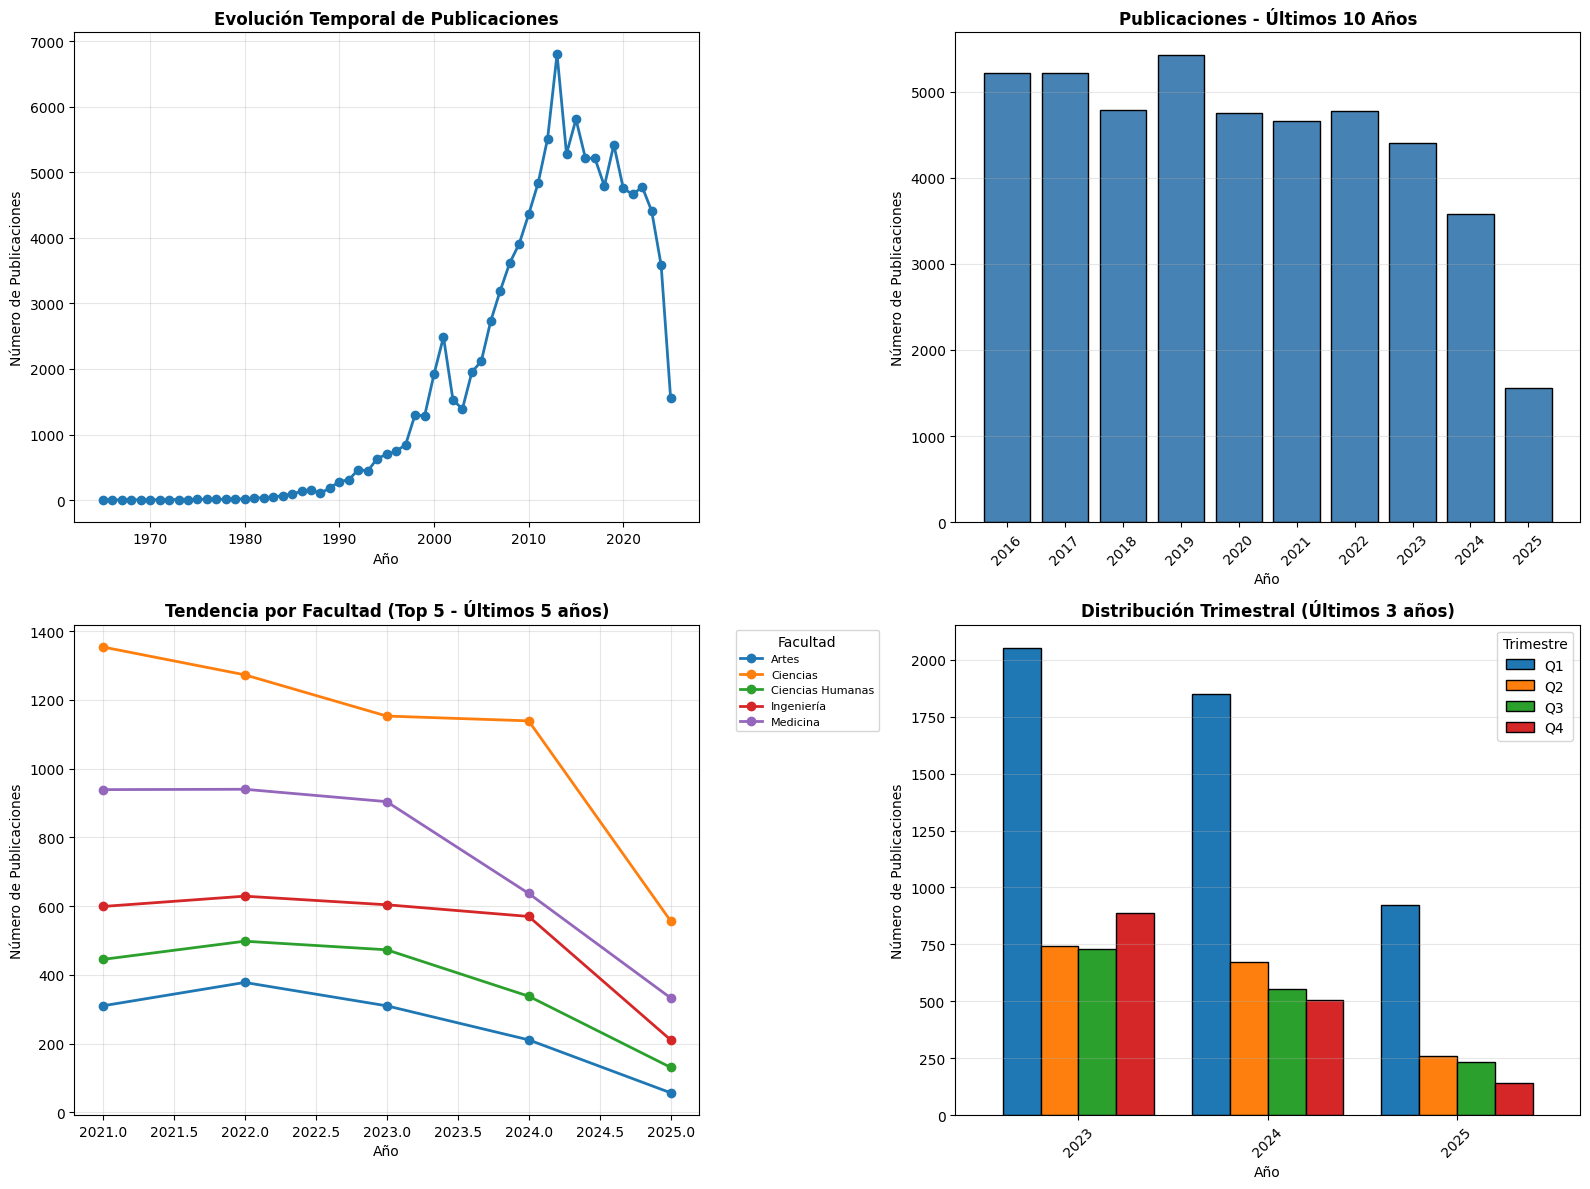


--- Estacionalidad por Mes ---


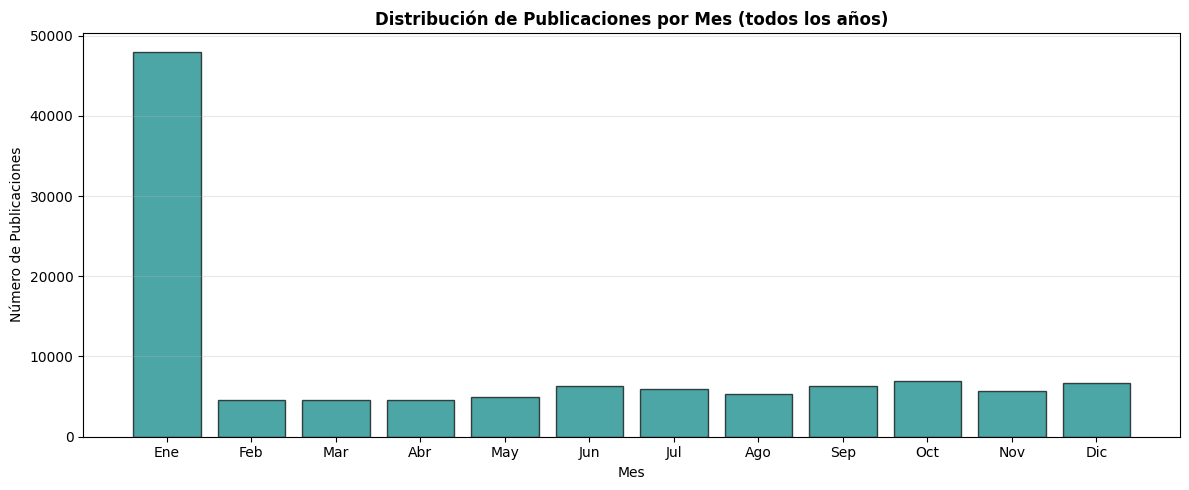


--- Tasa de Crecimiento por Facultad (últimos 5 años) ---


,min,max,count
Facultad,,,
Ciencias,2021,2025,5476
Medicina,2021,2025,3753
Ingeniería,2021,2025,2613
Ciencias Humanas,2021,2025,1885
Artes,2021,2025,1266
Ciencias Agrarias,2021,2025,914
Ciencias Económicas,2021,2025,749
Enfermería,2021,2025,742
Derecho,2021,2025,620


In [14]:
# Análisis Temporal de Publicaciones
print("="*60)
print("ANÁLISIS TEMPORAL DE PUBLICACIONES")
print("="*60)

# Convertir fecha a datetime si no se ha hecho
if 'fecha_dt' not in locals():
    fecha_dt = pd.to_datetime(productos_bogota["Fecha"], errors="coerce", dayfirst=True)

# Agregar columnas temporales al DataFrame
productos_bogota['año'] = fecha_dt.dt.year
productos_bogota['mes'] = fecha_dt.dt.month
productos_bogota['trimestre'] = fecha_dt.dt.quarter

# Filtrar datos con fecha válida
datos_temporales = productos_bogota[productos_bogota['año'].notna()].copy()

print(f"Registros con fecha válida: {len(datos_temporales)} ({len(datos_temporales)/len(productos_bogota)*100:.1f}%)")
print(f"Rango temporal: {datos_temporales['año'].min():.0f} - {datos_temporales['año'].max():.0f}")

# 1. Producción por año
print("\n--- Producción Anual ---")
prod_anual = datos_temporales['año'].value_counts().sort_index()
display(prod_anual.tail(10).to_frame("publicaciones"))

# 2. Estadísticas por facultad y año (Top 5 facultades)
print("\n--- Producción por Facultad (últimos 5 años) ---")
top_facultades = datos_temporales['Facultad'].value_counts().head(5).index
ultimos_5_anios = datos_temporales['año'].max() - 4

facultad_anio = datos_temporales[
    (datos_temporales['Facultad'].isin(top_facultades)) &
    (datos_temporales['año'] >= ultimos_5_anios)
].groupby(['Facultad', 'año']).size().unstack(fill_value=0)

display(facultad_anio)

# 3. Tendencia de crecimiento
print("\n--- Análisis de Tendencia ---")
# Calcular crecimiento año a año
crecimiento = prod_anual.pct_change() * 100
print(f"Crecimiento promedio anual: {crecimiento.mean():.2f}%")
print(f"Año con mayor crecimiento: {crecimiento.idxmax():.0f} ({crecimiento.max():.1f}%)")
print(f"Año con mayor producción: {prod_anual.idxmax():.0f} ({prod_anual.max()} publicaciones)")

# 4. Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Serie temporal completa
axes[0, 0].plot(prod_anual.index, prod_anual.values, marker='o', linewidth=2)
axes[0, 0].set_title('Evolución Temporal de Publicaciones', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Año')
axes[0, 0].set_ylabel('Número de Publicaciones')
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Últimos 10 años (barras)
ultimos_10 = prod_anual.tail(10)
axes[0, 1].bar(ultimos_10.index.astype(str), ultimos_10.values, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Publicaciones - Últimos 10 Años', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('Número de Publicaciones')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Gráfico 3: Tendencia por facultad (Top 5, últimos 5 años)
facultad_anio.T.plot(ax=axes[1, 0], marker='o', linewidth=2)
axes[1, 0].set_title('Tendencia por Facultad (Top 5 - Últimos 5 años)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Año')
axes[1, 0].set_ylabel('Número de Publicaciones')
axes[1, 0].legend(title='Facultad', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Distribución por trimestre (últimos 3 años)
ultimos_3_anios = datos_temporales['año'].max() - 2
datos_trimestre = datos_temporales[datos_temporales['año'] >= ultimos_3_anios]
trim_pivot = datos_trimestre.groupby(['año', 'trimestre']).size().unstack(fill_value=0)
trim_pivot.plot(kind='bar', ax=axes[1, 1], width=0.8, edgecolor='black')
axes[1, 1].set_title('Distribución Trimestral (Últimos 3 años)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Número de Publicaciones')
axes[1, 1].legend(title='Trimestre', labels=['Q1', 'Q2', 'Q3', 'Q4'])
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 5. Análisis de estacionalidad (publicaciones por mes)
print("\n--- Estacionalidad por Mes ---")
prod_mensual = datos_temporales['mes'].value_counts().sort_index()
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1, 13), [prod_mensual.get(i, 0) for i in range(1, 13)],
       color='teal', edgecolor='black', alpha=0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.set_title('Distribución de Publicaciones por Mes (todos los años)', fontsize=12, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Número de Publicaciones')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 6. Tasa de publicación por facultad (últimos 5 años)
print("\n--- Tasa de Crecimiento por Facultad (últimos 5 años) ---")
facultades_crecimiento = datos_temporales[
    datos_temporales['año'] >= ultimos_5_anios
].groupby('Facultad')['año'].agg(['min', 'max', 'count'])

display(facultades_crecimiento.sort_values('count', ascending=False).head(10))

# Limpiar columnas temporales
productos_bogota.drop(columns=['año', 'mes', 'trimestre'], inplace=True)

## 2.5. Metadata Quality and Text Field Analysis ('Titulo original', 'Descripción original')

In [15]:
# Análisis de columnas de texto (Titulo original y Descripción)
print("="*60)
print("ANÁLISIS DE COLUMNAS DE TEXTO")
print("="*60)

# Títulos
productos_bogota['titulo_length'] = productos_bogota['Título original'].fillna('').astype(str).str.len()
display(pd.DataFrame({
    'columna': ['Título original'],
    'total': [len(productos_bogota)],
    'no_nulos': [productos_bogota['Título original'].notna().sum()],
    'vacios': [(productos_bogota['Título original'].fillna('').astype(str).str.strip() == '').sum()],
    'longitud_promedio': [productos_bogota['titulo_length'].mean()],
    'longitud_mediana': [productos_bogota['titulo_length'].median()],
    'longitud_min': [productos_bogota['titulo_length'].min()],
    'longitud_max': [productos_bogota['titulo_length'].max()]
}))

# Descripción/Abstracts
productos_bogota['desc_length'] = productos_bogota['Descripción original'].fillna('').astype(str).str.len()
desc_no_nulos = productos_bogota['Descripción original'].notna()
desc_cortos = (productos_bogota['desc_length'] > 0) & (productos_bogota['desc_length'] < 50)

display(pd.DataFrame({
    'columna': ['Descripción original'],
    'total': [len(productos_bogota)],
    'no_nulos': [desc_no_nulos.sum()],
    'vacios': [(productos_bogota['desc_length'] == 0).sum()],
    'muy_cortos (<50 chars)': [desc_cortos.sum()],
    'longitud_promedio': [productos_bogota.loc[desc_no_nulos, 'desc_length'].mean()],
    'longitud_mediana': [productos_bogota.loc[desc_no_nulos, 'desc_length'].median()],
    'longitud_min': [productos_bogota.loc[desc_no_nulos, 'desc_length'].min()],
    'longitud_max': [productos_bogota.loc[desc_no_nulos, 'desc_length'].max()]
}))

# Limpiar columnas temporales
productos_bogota.drop(columns=['titulo_length', 'desc_length'], inplace=True)

# Mostrar ejemplos de abstracts muy cortos
if desc_cortos.sum() > 0:
    print("\nEjemplos de descripciones muy cortas:")
    display(productos_bogota.loc[desc_cortos, ['Título original', 'Descripción original']].head(5))

ANÁLISIS DE COLUMNAS DE TEXTO


,columna,total,no_nulos,vacios,longitud_promedio,longitud_mediana,longitud_min,longitud_max
0,Título original,109836,109835,1,95.878319,92.0,0,978


,columna,total,no_nulos,vacios,muy_cortos (<50 chars),longitud_promedio,longitud_mediana,longitud_min,longitud_max
0,Descripción original,109836,69928,39908,7023,1349.212747,1191.0,1,23677



Ejemplos de descripciones muy cortas:


,Título original,Descripción original
81,EFECTO DE LA VARIABILIDAD CLIMÁTICA EN PRODUCC...,No Reportado
90,VULNERABILIDAD DE ESTRUCTURAS DE CONCRETO REFO...,No Reportado
91,DISEÑO DE SISTEMA ELECTRÓNICO PARA EL MONITORE...,No Reportado
92,TÉCNICAS PARA IDENTIFICAR FALLAS ELÉCTRICAS EN...,No Reportado
94,RESISTENCIA A LA CORROSIÓN DEL RECUBRIMIENTO D...,No Reportado


In [16]:
print("="*60)
print("ANÁLISIS DE CALIDAD DE DATOS - VALORES FALTANTES Y CONVENCIONES")
print("="*60)

# Check each column for conventions
columnas_revisar = ['Título original', 'Descripción original', 'Idioma',
                    'Fuente', 'Tipo', 'Revista / Conferencia', 'DOI', 'ISBN', 'ISSN']

resumen_calidad = []
for col in columnas_revisar:
    if col not in productos_bogota.columns:
        continue
    nulos_reales = productos_bogota[col].isna().sum()
    nulos_convencion = productos_bogota[col].apply(es_valor_nulo_convencion).sum() - nulos_reales
    vacios = (productos_bogota[col].fillna('').astype(str).str.strip() == '').sum() - nulos_reales
    resumen_calidad.append({
        'Columna': col,
        'NaN reales': nulos_reales,
        'Vacíos ("")': vacios,
        'Convenciones (e.g. No Reportado)': nulos_convencion,
        'Total efectivamente nulos': nulos_reales + vacios + nulos_convencion,
        '% nulo efectivo': round((nulos_reales + vacios + nulos_convencion) / len(productos_bogota) * 100, 2),
        'Únicos válidos': productos_bogota[col].dropna().nunique()
    })

resumen_calidad_df = pd.DataFrame(resumen_calidad)
display(resumen_calidad_df)

# Rows with empty title
sin_titulo = productos_bogota[
    productos_bogota['Título original'].fillna('').astype(str).str.strip() == ''
]
print(f"\nFilas sin título: {len(sin_titulo)}")
display(sin_titulo[['Tipo', 'Fuente', 'Facultad', 'Descripción original']].head(10))

ANÁLISIS DE CALIDAD DE DATOS - VALORES FALTANTES Y CONVENCIONES


,Columna,NaN reales,"Vacíos ("""")",Convenciones (e.g. No Reportado),Total efectivamente nulos,% nulo efectivo,Únicos válidos
0,Título original,1,0,0,1,0.00,104658
1,Descripción original,39908,0,5849,45757,41.66,59491
2,Idioma,7733,0,0,7733,7.04,30
3,Fuente,0,0,0,0,0.00,12
4,Tipo,0,0,0,0,0.00,30
5,Revista / Conferencia,41852,0,0,41852,38.10,13456
6,ISBN,100105,0,0,100105,91.14,6073
7,ISSN,66136,0,0,66136,60.21,9587



Filas sin título: 1


,Tipo,Fuente,Facultad,Descripción original
49067,Proyecto,HERMES,Ciencias Humanas,NaN


## 2.6 Linguistic Metadata Analysis ('Idioma')

ANÁLISIS DETALLADO DE IDIOMA

Distribución completa de idiomas:


,frecuencia,porcentaje
Idioma,,
Español,60001,54.63
Inglés,37254,33.92
NaN,7733,7.04
Portugués,1119,1.02
Galicia,1110,1.01
Indonesio,632,0.58
Francés,454,0.41
Italiano,432,0.39
Alemán,374,0.34



Registros sin idioma especificado: 7733
De estos, tienen descripción: 410

Idioma por Facultad (top 8 idiomas):


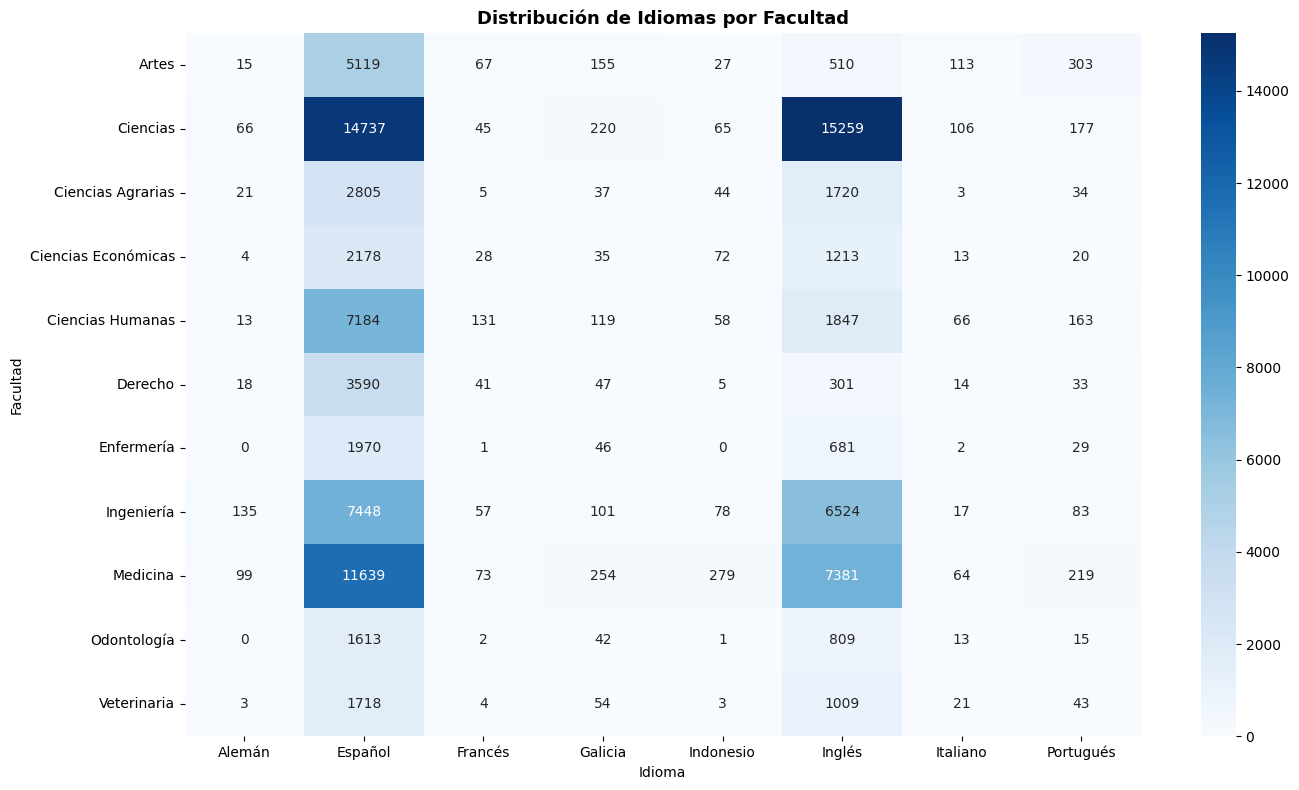


Idioma por Tipo de producción (top 8 idiomas):


Idioma,Alemán,Español,Francés,Galicia,Indonesio,Inglés,Italiano,Portugués
Tipo,,,,,,,,
Apoyo a la investigación,0,0,0,0,0,12,0,0
Artículo de conferencia,60,1947,8,17,107,3687,10,31
Artículo de revista,167,12504,83,189,322,25863,123,197
Capítulo de libro,22,5140,97,158,28,1056,72,73
Colección científica,1,113,0,6,0,3,0,2
Comentario,0,0,0,0,0,3,1,0
Datos,5,17,7,0,1,76,1,3
Desarrollo de software,10,85,1,4,3,6,1,35
Editorial,30,103,6,1,99,305,0,2



Registros sin idioma: 7733
Inferencia heurística para registros sin idioma:


,conteo
Título original,
Español (inferido),4165
Inglés (inferido),2030
Indeterminado,1538


In [17]:
print("="*60)
print("ANÁLISIS DETALLADO DE IDIOMA")
print("="*60)

print("\nDistribución completa de idiomas:")
idioma_counts = productos_bogota['Idioma'].value_counts(dropna=False)
display(idioma_counts.to_frame("frecuencia").assign(
    porcentaje=lambda df: (df['frecuencia'] / len(productos_bogota) * 100).round(2)
))

productos_con_desc = productos_bogota['Descripción original'].notna()
productos_sin_idioma = productos_bogota['Idioma'].isna()

print(f"\nRegistros sin idioma especificado: {productos_sin_idioma.sum()}")
print(f"De estos, tienen descripción: {(productos_sin_idioma & productos_con_desc).sum()}")

# Language vs Faculty heatmap
print("\nIdioma por Facultad (top 8 idiomas):")
top_idiomas = productos_bogota['Idioma'].value_counts().head(8).index
idioma_facultad = productos_bogota[
    productos_bogota['Idioma'].isin(top_idiomas)
].groupby(['Facultad', 'Idioma']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(idioma_facultad, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Distribución de Idiomas por Facultad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Language vs Tipo
print("\nIdioma por Tipo de producción (top 8 idiomas):")
idioma_tipo = productos_bogota[
    productos_bogota['Idioma'].isin(top_idiomas)
].groupby(['Tipo', 'Idioma']).size().unstack(fill_value=0)
display(idioma_tipo)

sin_idioma_mask = productos_bogota['Idioma'].apply(es_valor_nulo_convencion)
print(f"\nRegistros sin idioma: {sin_idioma_mask.sum()}")
idiomas_inferidos = productos_bogota.loc[sin_idioma_mask, 'Título original'].apply(inferir_idioma_heuristico)
print("Inferencia heurística para registros sin idioma:")
display(idiomas_inferidos.value_counts().to_frame("conteo"))

## 2.7. Categorical Structure Analysis ('Tipo', 'Fuente', 'Facultad', 'Revista / Conferencia')

ANÁLISIS DE COLUMNAS CATEGÓRICAS

--- Tipo ---
Categorías únicas: 30
Top 10:


,frecuencia
Tipo,
Artículo de revista,41706
Tesis Maestría,17660
Ponencias en eventos especializados,10422
Proyecto,10152
Capítulo de libro,7767
Libro,6071
Artículo de conferencia,5979
Tesis Doctorado,2408
Tesis Especialización,1561


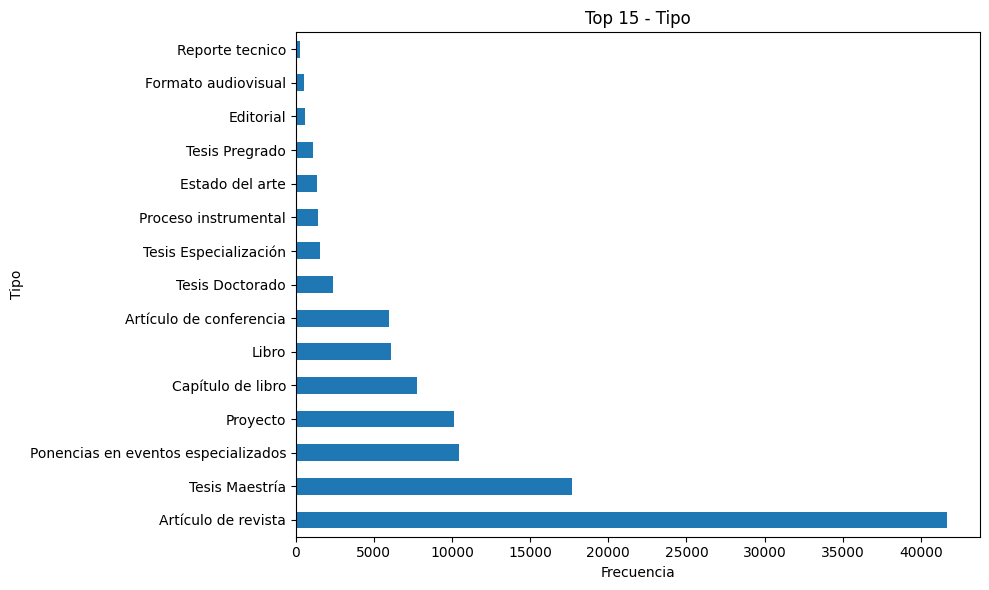


--- Fuente ---
Categorías únicas: 12
Top 10:


,frecuencia
Fuente,
SARA,49040
SCOPUS,23756
RepositorioUNAL,12287
HERMES,10152
CURADURIA,4359
RG,3977
RevistasUNAL,2143
WEB OF SCIENCE,2013
BibliotecasUNAL,1169


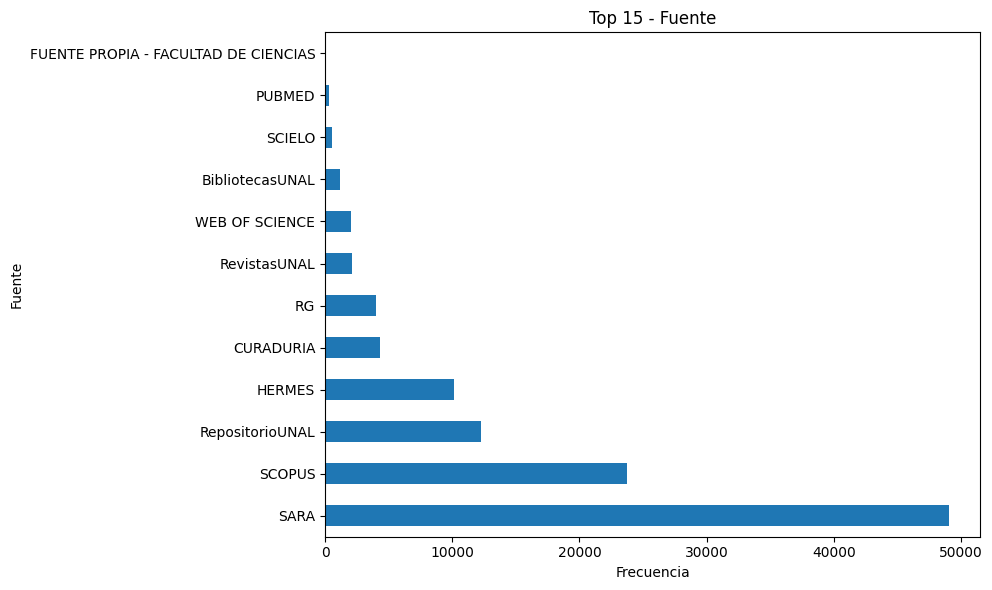


--- Facultad ---
Categorías únicas: 11
Top 10:


,frecuencia
Facultad,
Ciencias,33701
Medicina,21115
Ingeniería,15228
Ciencias Humanas,10415
Artes,7640
Ciencias Agrarias,4884
Derecho,4268
Ciencias Económicas,3758
Veterinaria,3256


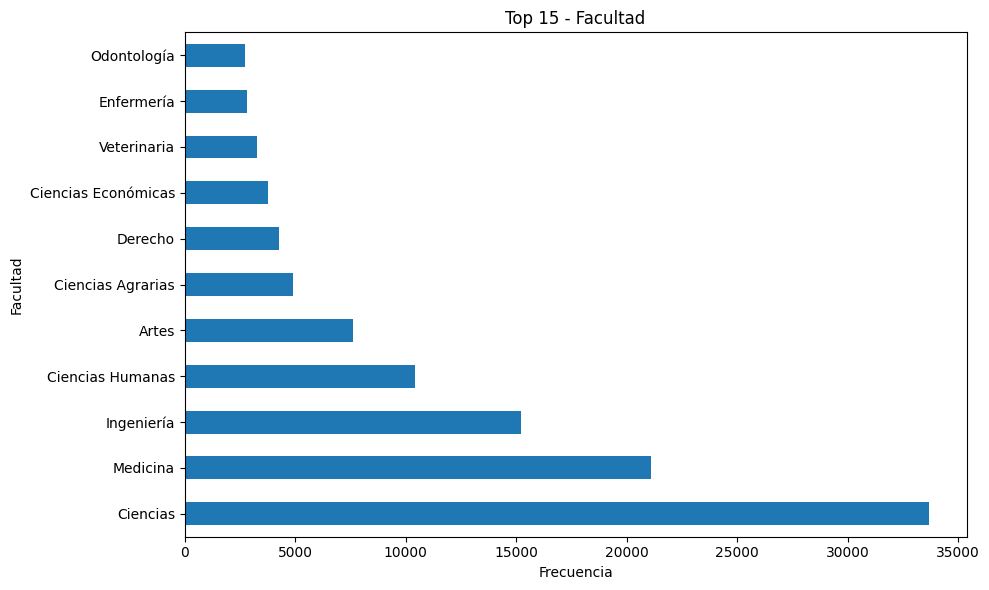


--- Revista / Conferencia ---
Categorías únicas: 13457
Top 10:


,frecuencia
Revista / Conferencia,
NaN,41852
Universidad Nacional de Colombia,12150
Revista de la Facultad de Medicína,1005
Revista Colombiana de Física,666
Biomédica,577
Agronomía Colombiana,511
Ingeniería e Investigación,493
Revista de Salud Pública,487
The Journal of High Energy Physics,444


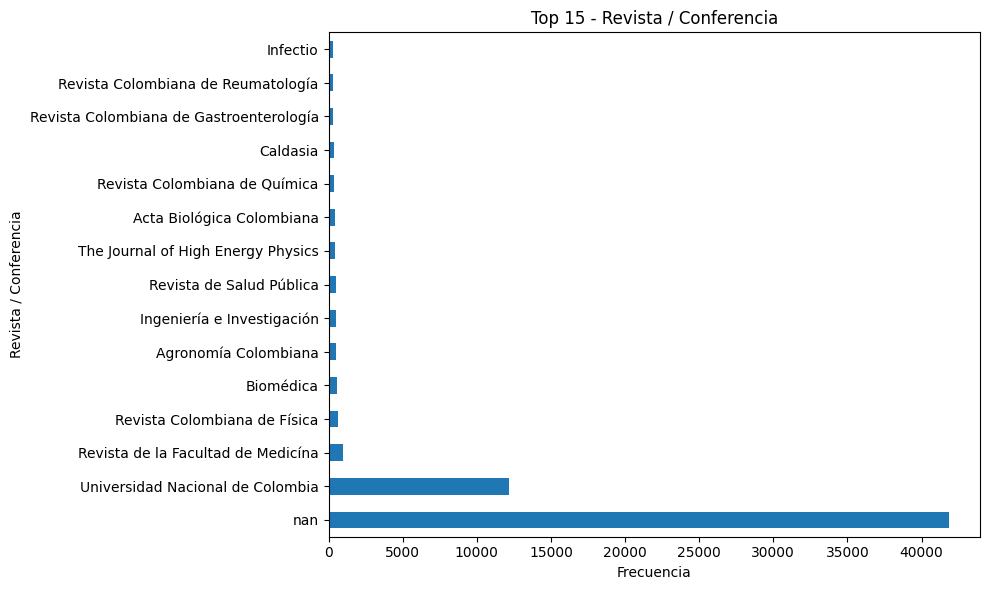

In [18]:
# Análisis de columnas categóricas importantes
print("="*60)
print("ANÁLISIS DE COLUMNAS CATEGÓRICAS")
print("="*60)

columnas_categoricas = ['Tipo', 'Fuente', 'Facultad', 'Revista / Conferencia']

for col in columnas_categoricas:
    print(f"\n--- {col} ---")
    conteo = productos_bogota[col].value_counts(dropna=False)
    print(f"Categorías únicas: {productos_bogota[col].nunique(dropna=False)}")
    print(f"Top 10:")
    display(conteo.head(10).to_frame("frecuencia"))

    # Visualización
    fig, ax = plt.subplots(figsize=(10, 6))
    conteo.head(15).plot(kind='barh', ax=ax)
    ax.set_title(f'Top 15 - {col}')
    ax.set_xlabel('Frecuencia')
    plt.tight_layout()
    plt.show()

RELACIÓN: FUENTE x FACULTAD x TIPO
Top fuentes por facultad:


Facultad,Artes,Ciencias,Ciencias Agrarias,Ciencias Económicas,Ciencias Humanas,Derecho,Enfermería,Ingeniería,Medicina,Odontología,Veterinaria
Fuente,,,,,,,,,,,
BibliotecasUNAL,111,328,45,51,134,64,46,126,174,53,37
CURADURIA,1,40,515,4,10,0,4,12,3756,15,2
HERMES,808,3422,508,304,996,507,209,1497,1182,371,348
RG,2,143,724,18,22,277,6,1133,1643,6,3
RepositorioUNAL,974,3350,433,823,1121,619,294,2227,2077,185,184
RevistasUNAL,147,753,45,102,455,130,51,166,189,66,39
SARA,5291,14114,1581,1860,6250,2475,1619,5678,6642,1509,2021
SCIELO,19,204,23,21,48,7,35,51,129,18,8
SCOPUS,245,10602,929,439,1089,86,455,4016,4895,442,558



Top fuentes por tipo de producción:


Tipo,Artículo de conferencia,Artículo de revista,Capítulo de libro,Colección científica,Datos,Desarrollo de software,Editorial,Estado del arte,Formato audiovisual,Libro,...,Ponencias en eventos especializados,Posters presentados,Preimpresión,Proceso instrumental,Proyecto,Reporte tecnico,Tesis Doctorado,Tesis Especialización,Tesis Maestría,Tesis Pregrado
Fuente,,,,,,,,,,,,,,,,,,,,,
BibliotecasUNAL,0,0,0,0,0,0,0,0,0,304,...,0,0,0,0,0,0,25,95,187,558
CURADURIA,1249,1662,681,0,0,0,0,0,0,549,...,0,0,0,0,0,210,0,0,0,0
HERMES,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,10152,0,0,0,0,0
RG,745,2425,246,0,144,1,0,0,0,158,...,0,108,44,0,0,48,0,0,0,0
RepositorioUNAL,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1159,906,9717,505
RevistasUNAL,0,2143,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SARA,1246,13946,6470,90,0,197,0,0,495,5036,...,10422,0,0,1425,0,0,1224,560,7756,10
SCIELO,0,563,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SCOPUS,2739,18986,370,0,0,0,480,1156,0,24,...,0,0,1,0,0,0,0,0,0,0


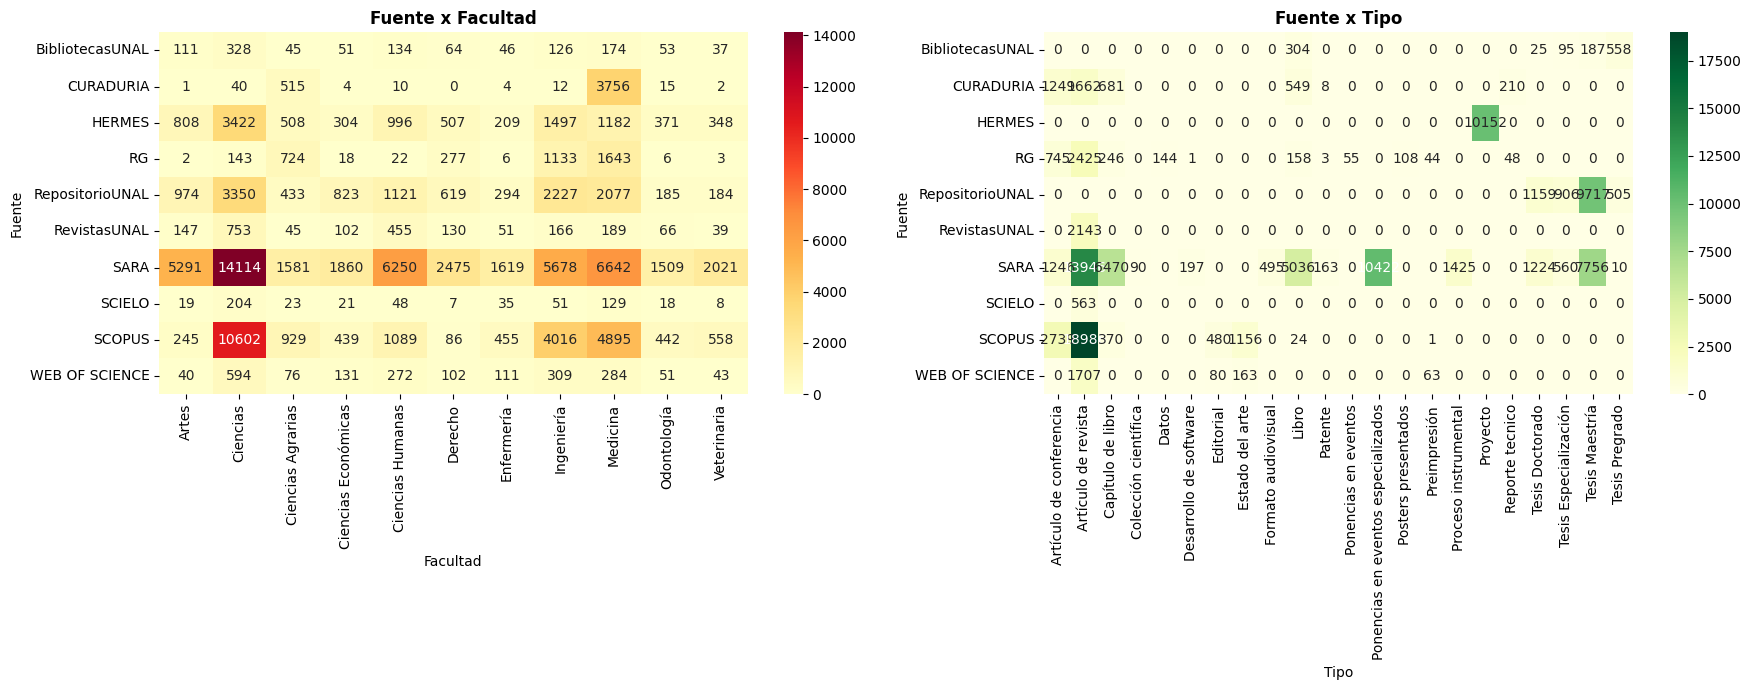

In [19]:
print("="*60)
print("RELACIÓN: FUENTE x FACULTAD x TIPO")
print("="*60)

# Fuente vs Facultad
top_fuentes = productos_bogota['Fuente'].value_counts().head(10).index
fuente_facultad = productos_bogota[
    productos_bogota['Fuente'].isin(top_fuentes)
].groupby(['Fuente', 'Facultad']).size().unstack(fill_value=0)

print("Top fuentes por facultad:")
display(fuente_facultad)

# Fuente vs Tipo
fuente_tipo = productos_bogota[
    productos_bogota['Fuente'].isin(top_fuentes)
].groupby(['Fuente', 'Tipo']).size().unstack(fill_value=0)

print("\nTop fuentes por tipo de producción:")
display(fuente_tipo)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(fuente_facultad, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Fuente x Facultad', fontsize=12, fontweight='bold')
sns.heatmap(fuente_tipo, annot=True, fmt='d', cmap='YlGn', ax=axes[1])
axes[1].set_title('Fuente x Tipo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.8. Authorship Structure Analysis ('Coautores')

ANÁLISIS DE COAUTORES


count    109836.000000
mean         26.984067
std         237.097728
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max        4289.000000
Name: num_coautores, dtype: float64


Total de nombres únicos de coautores: 99589


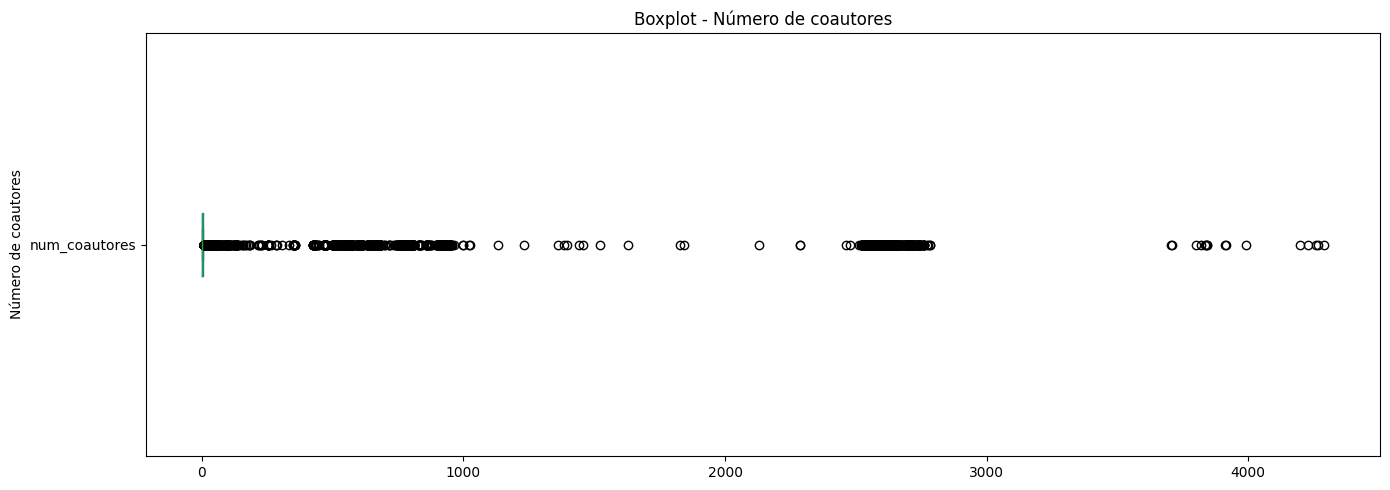

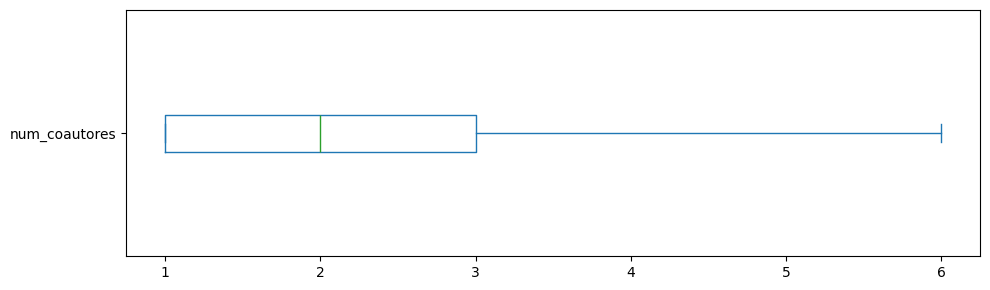

In [20]:
# Análisis de Coautores
print("="*60)
print("ANÁLISIS DE COAUTORES")
print("="*60)

productos_bogota['num_coautores'] = productos_bogota['Coautores'].apply(contar_coautores)
productos_bogota.loc[productos_bogota['Coautores'].isna(), 'num_coautores'] = 0

display(productos_bogota['num_coautores'].describe())

todos_coautores = []
for coautores in productos_bogota['Coautores']:
    todos_coautores.extend(extraer_coautores(coautores))

coautores_counter = Counter(todos_coautores)
print(f"\nTotal de nombres únicos de coautores: {len(coautores_counter)}")

fig, ax = plt.subplots(figsize=(14, 5))
productos_bogota['num_coautores'].plot(kind='box', vert=False, ax=ax)
ax.set_title('Boxplot - Número de coautores')
ax.set_ylabel('Número de coautores')
plt.tight_layout()
plt.show()

productos_bogota['num_coautores'].plot(kind='box', vert=False, figsize=(10, 3), showfliers=False)
plt.tight_layout()
plt.show()

INSPECCIÓN DE FILAS CON MUCHOS COAUTORES


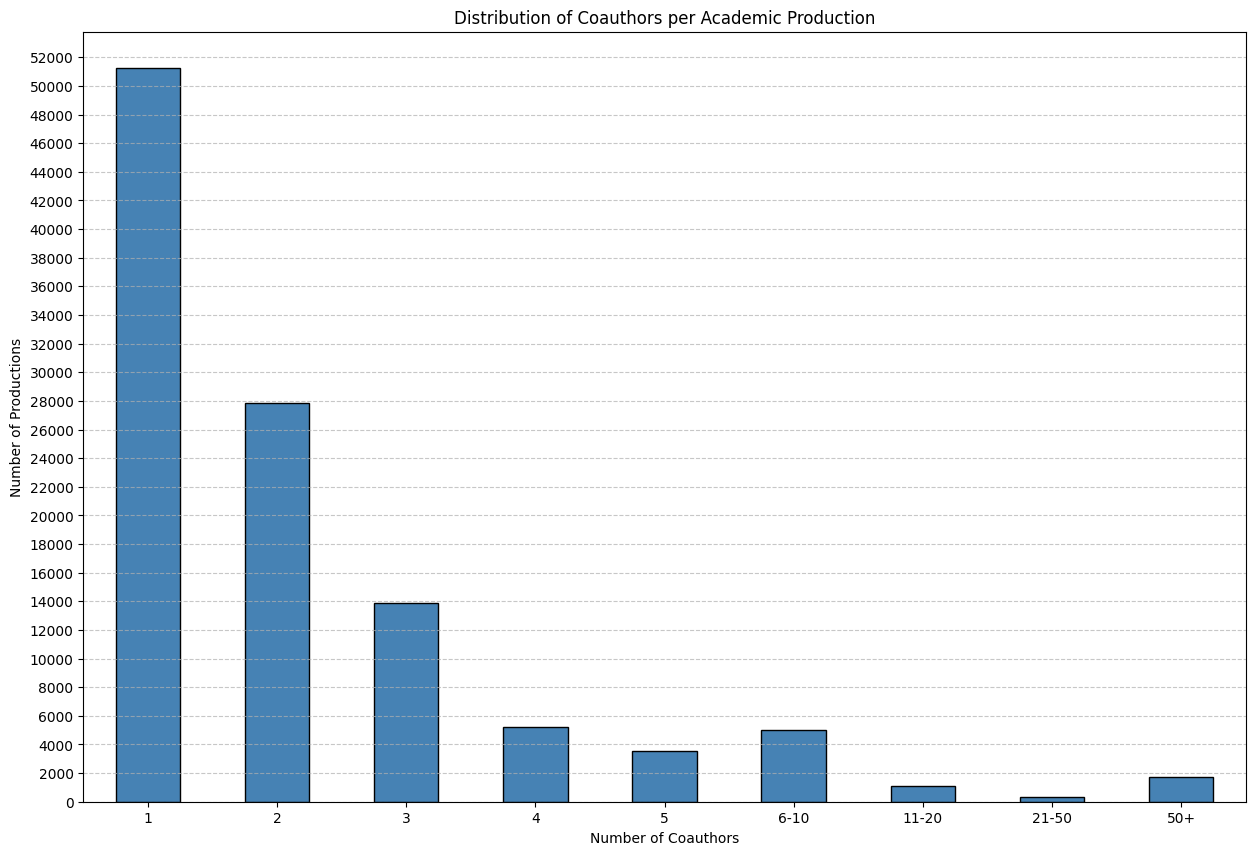

Filas con más de 50 coautores: 1702


,Título original,Descripción original,Revista / Conferencia,Coautores,Doi,ISBN,ISSN,Citaciones,Idioma,Fecha,Tipo,Fuente,Enlace,Facultad,num_coautores,author_groups
66269,Combination of the W boson polarization measur...,The combination of measurements of the W boson...,The Journal of High Energy Physics,"Sandoval Usme Carlos Eduardo, Paredes Hernande...",10.1007/JHEP08(2020)051,NaN,"10298479, 11266708",16.0,Inglés,08/01/2020,Artículo de revista,SCOPUS,http://dx.doi.org/10.1007/JHEP08(2020)051 - ...,Ciencias,4289,50+
68028,Combinations of single-top-quark production cr...,This paper presents the combinations of single...,The Journal of High Energy Physics,"Sandoval Usme Carlos Eduardo, Paredes Hernande...",10.1007/JHEP05(2019)088,NaN,"10298479, 11266708",21.0,Inglés,05/01/2019,Artículo de revista,SCOPUS,http://dx.doi.org/10.1007/JHEP05(2019)088 - ...,Ciencias,4267,50+
69944,Combination of inclusive and differential tt¯ ...,This paper presents combinations of inclusive ...,The Journal of High Energy Physics,"Sandoval Usme Carlos Eduardo, Castañeda Acero ...",10.1007/JHEP04(2018)033,NaN,"10298479, 11266708",10.0,Inglés,01/01/2018,Artículo de revista,SCOPUS,http://dx.doi.org/10.1007/JHEP04(2018)033 - ...,Ciencias,4259,50+
74338,Combined Measurement of the Higgs Boson Mass i...,A measurement of the Higgs boson mass is prese...,Physical Review Letters,"Sandoval Usme Carlos Eduardo, Martinez Paez Jo...",10.1103/PhysRevLett.114.191803,NaN,"00319007, 10797114",1050.0,Inglés,14/05/2015,Artículo de revista,SCOPUS,http://dx.doi.org/10.1103/PhysRevLett.114.1918...,Ciencias,4229,50+
72861,Measurements of the Higgs boson production and...,Combined ATLAS and CMS measurements of the Hig...,The Journal of High Energy Physics,"Sandoval Usme Carlos Eduardo, Martinez Paez Jo...",10.1007/JHEP08(2016)045,NaN,10298479,706.0,Inglés,08/01/2016,Artículo de revista,SCOPUS,http://dx.doi.org/10.1007/JHEP08(2016)045 - ...,Ciencias,4197,50+


In [21]:
print("=" * 60)
print("INSPECCIÓN DE FILAS CON MUCHOS COAUTORES")
print("=" * 60)

# Discretization with custom bins
bins = [0, 1, 2, 3, 4, 5, 10, 20, 50, 5000]
labels = ['1', '2', '3', '4', '5', '6-10', '11-20', '21-50', '50+']

productos_bogota['author_groups'] = pd.cut(productos_bogota['num_coautores'], bins=bins, labels=labels)

# Plot
ax = productos_bogota['author_groups'].value_counts()[labels].plot(
    kind='bar', 
    color='steelblue', 
    edgecolor='black',
    figsize=(15, 10)
)

ax.set_title("Distribution of Coauthors per Academic Production")
ax.set_xlabel("Number of Coauthors")
ax.set_ylabel("Number of Productions")
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.locator_params(axis='y', nbins=30)
plt.xticks(rotation=0)
plt.show()

productos_bogota.drop(columns=['author_groups'])

umbral_outlier = 50  # adjust as needed
outliers_coautores = productos_bogota[productos_bogota['num_coautores'] > umbral_outlier]

print(f"Filas con más de {umbral_outlier} coautores: {len(outliers_coautores)}")
display(outliers_coautores.sort_values('num_coautores', ascending=False).head())

ANÁLISIS COMPLEMENTARIO COAUTORES x TIPO
Coautores por Tipo de producción:


,mean,median,max,count
Tipo,,,,
Artículo de revista,67.533952,2.0,4289,41706
Estado del arte,15.893633,3.0,2641,1335
Estudio multicéntrico,11.000000,11.0,11,1
Estudio observacional,11.000000,11.0,14,2
Editorial,4.088028,1.0,923,568
Reporte de caso,4.000000,3.0,8,9
Errata,3.500000,2.0,10,8
Comentario,3.500000,3.0,5,4
Artículo de conferencia,3.445392,2.0,550,5979


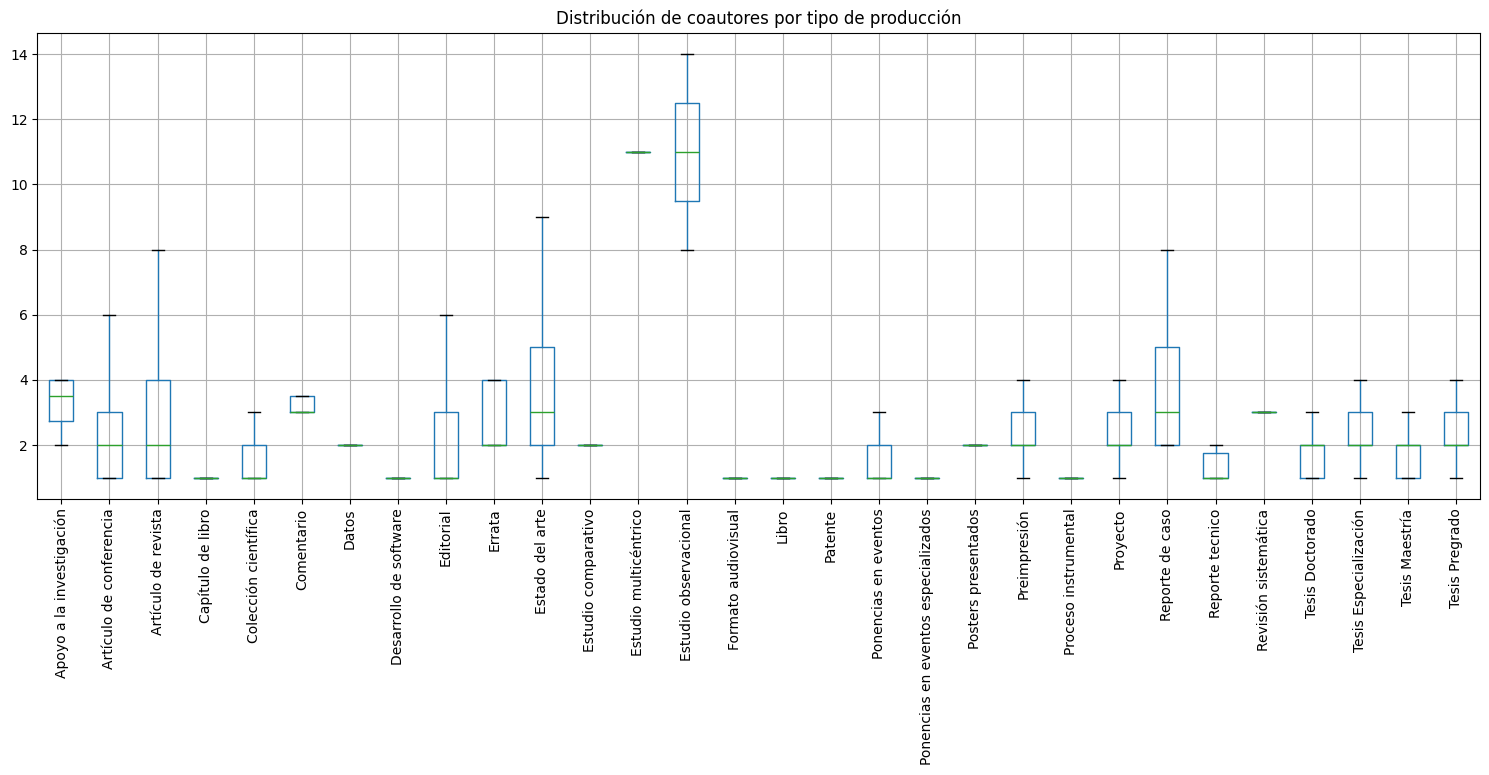

In [22]:
print("="*60)
print("ANÁLISIS COMPLEMENTARIO COAUTORES x TIPO")
print("="*60)

# --- A. Correlation between num_coautores and Tipo ---
print("Coautores por Tipo de producción:")
coautores_tipo = productos_bogota.groupby('Tipo')['num_coautores'].agg(
    ['mean', 'median', 'max', 'count']
).sort_values('mean', ascending=False)
display(coautores_tipo)

fig, ax = plt.subplots(figsize=(15, 8))
productos_bogota.boxplot(column='num_coautores', by='Tipo', ax=ax,
                          showfliers=False, rot=90)
ax.set_title('Distribución de coautores por tipo de producción')
ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 2.9. Author frequency

ANÁLISIS DE DISTRIBUCIÓN POR AUTOR ACTIVO
Analizando distribución de docentes activos desde la columna 'Coautores'...
Total de autores activos únicos: 1934
Total de menciones de autores activos: 133710
Producciones con al menos 1 docente activo: 109836/109836 (100.0%)

Estadísticas de producciones por docente activo:


count    1934.000000
mean       69.136505
std        81.405972
min         1.000000
25%        19.000000
50%        43.000000
75%        89.000000
max      1024.000000
Name: count, dtype: float64


Top 20 docentes activos más frecuentes:


,producciones
Sandoval Usme Carlos Eduardo,1024
Milanes Carreño Diego Alejandro,980
Sánchez Pedraza Ricardo,602
Romero Castro Edgar Eduardo,580
Giraldo Gutierrez Liliana,567
Eslava Schmalbach Javier Hernando,545
Olaya Flórez Jhon Jairo,542
Cortes Luna Jorge Alberto,520
González Osorio Fabio Augusto,516
Martinez Rodriguez Fleming,515



--- Distribución Long Tail (Docentes Activos) ---
Docentes con 1 producción: 8 (0.4%)
Docentes con 2-5 producciones: 96 (5.0%)
Docentes con 6-10 producciones: 136 (7.0%)
Docentes con >10 producciones: 1694 (87.6%)


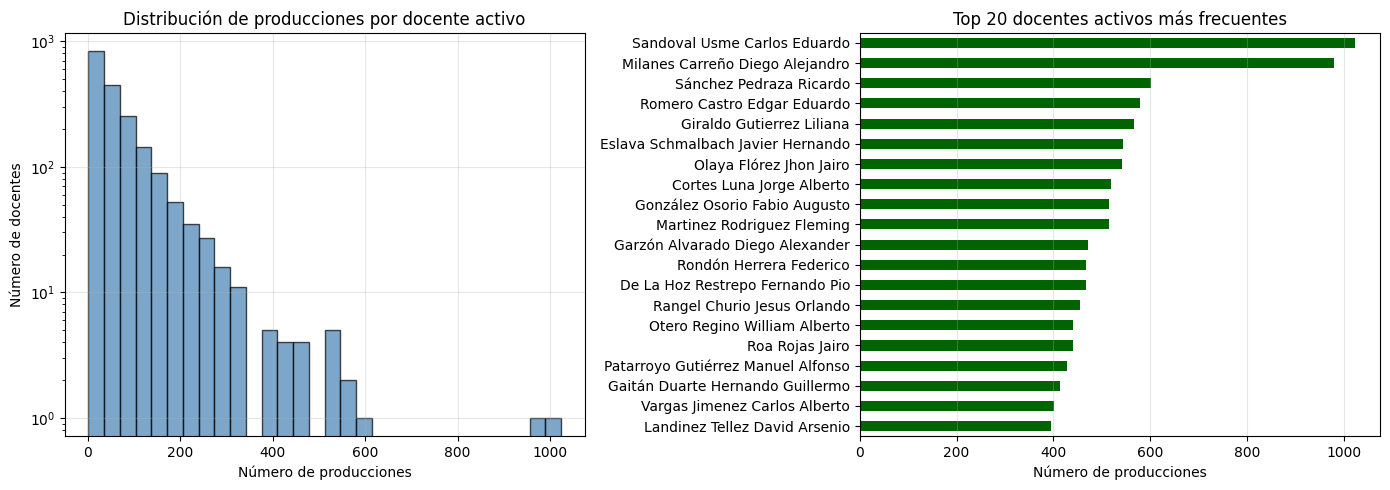

In [23]:
# Distribución por Profesor/Autor principal (SOLO DOCENTES ACTIVOS)
print("="*60)
print("ANÁLISIS DE DISTRIBUCIÓN POR AUTOR ACTIVO")
print("="*60)

print("Analizando distribución de docentes activos desde la columna 'Coautores'...")

# Set de docentes activos normalizados para lookup rápido
if 'docentes_activos_nombres' not in locals():
    docentes_activos_nombres = set(
        docentes_investigadores_activos['Nombre']
        .dropna()
        .apply(normalizar_para_match)
    )

# Filtrar solo coautores que son docentes activos
coautores_activos = []
for coautores in productos_bogota['Coautores']:
    nombres = extraer_coautores(coautores)
    activos = [n for n in nombres if normalizar_para_match(n) in docentes_activos_nombres]
    coautores_activos.extend(activos)

autor_counts = pd.Series(coautores_activos).value_counts()

print(f"Total de autores activos únicos: {len(autor_counts)}")
print(f"Total de menciones de autores activos: {len(coautores_activos)}")

# Cobertura
papers_con_activos = productos_bogota['Coautores'].apply(
    lambda x: tiene_docente_activo(x, docentes_activos_nombres)
).sum()
print(f"Producciones con al menos 1 docente activo: {papers_con_activos}/{len(productos_bogota)} ({papers_con_activos/len(productos_bogota)*100:.1f}%)")

print(f"\nEstadísticas de producciones por docente activo:")
display(autor_counts.describe())

print(f"\nTop 20 docentes activos más frecuentes:")
display(autor_counts.head(20).to_frame("producciones"))

# Análisis Long Tail para activos
autores_con_1 = (autor_counts == 1).sum()
autores_con_2_5 = ((autor_counts >= 2) & (autor_counts <= 5)).sum()
autores_con_6_10 = ((autor_counts >= 6) & (autor_counts <= 10)).sum()
autores_con_mas_10 = (autor_counts > 10).sum()

print("\n--- Distribución Long Tail (Docentes Activos) ---")
print(f"Docentes con 1 producción: {autores_con_1} ({autores_con_1/len(autor_counts)*100:.1f}%)")
print(f"Docentes con 2-5 producciones: {autores_con_2_5} ({autores_con_2_5/len(autor_counts)*100:.1f}%)")
print(f"Docentes con 6-10 producciones: {autores_con_6_10} ({autores_con_6_10/len(autor_counts)*100:.1f}%)")
print(f"Docentes con >10 producciones: {autores_con_mas_10} ({autores_con_mas_10/len(autor_counts)*100:.1f}%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(autor_counts, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].set_title('Distribución de producciones por docente activo')
axes[0].set_xlabel('Número de producciones')
axes[0].set_ylabel('Número de docentes')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# Top 20 activos
autor_counts.head(20).sort_values().plot(kind='barh', ax=axes[1], color='darkgreen')
axes[1].set_title('Top 20 docentes activos más frecuentes')
axes[1].set_xlabel('Número de producciones')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


COAUTORES ACTIVOS POR FACULTAD


,Facultad,Producciones,Docentes activos únicos,Menciones activas totales,Promedio menciones por docente
5,Ciencias,33701,1037,41681,40.193828
8,Medicina,21115,904,26491,29.304204
0,Ingeniería,15228,730,19108,26.175342
4,Ciencias Humanas,10415,550,11372,20.676364
1,Artes,7640,410,8550,20.853659
2,Ciencias Agrarias,4884,361,6250,17.313019
6,Derecho,4268,184,4603,25.016304
3,Ciencias Económicas,3758,280,4389,15.675000
10,Veterinaria,3256,233,3961,17.000000
7,Enfermería,2838,242,3723,15.384298


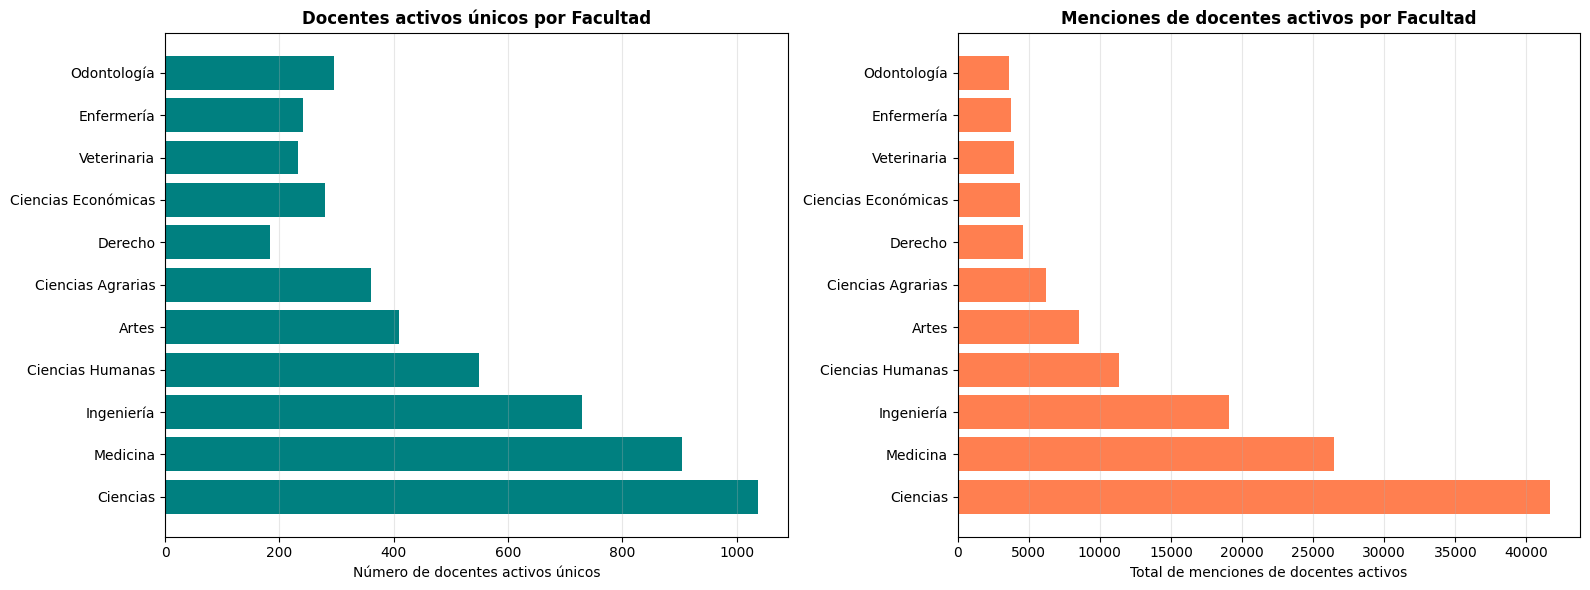

In [24]:
# Análisis adicional: coautoría activa por facultad
print("\n" + "="*60)
print("COAUTORES ACTIVOS POR FACULTAD")
print("="*60)

# Construir tabla de docentes activos por facultad
activos_por_facultad = []

for facultad in productos_bogota['Facultad'].dropna().unique():
    subset = productos_bogota[productos_bogota['Facultad'] == facultad]
    
    autores_facultad = []
    for coautores in subset['Coautores']:
        nombres = extraer_coautores(coautores)
        activos = [n for n in nombres if normalizar_para_match(n) in docentes_activos_nombres]
        autores_facultad.extend(activos)
    
    if len(autores_facultad) > 0:
        counts = pd.Series(autores_facultad).value_counts()
        activos_por_facultad.append({
            'Facultad': facultad,
            'Producciones': len(subset),
            'Docentes activos únicos': len(counts),
            'Menciones activas totales': len(autores_facultad),
            'Promedio menciones por docente': counts.mean()
        })

activos_facultad_df = pd.DataFrame(activos_por_facultad).sort_values('Menciones activas totales', ascending=False)
display(activos_facultad_df)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: docentes activos únicos por facultad
axes[0].barh(activos_facultad_df['Facultad'], activos_facultad_df['Docentes activos únicos'], color='teal')
axes[0].set_xlabel('Número de docentes activos únicos')
axes[0].set_title('Docentes activos únicos por Facultad', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Gráfico 2: menciones activas totales por facultad
axes[1].barh(activos_facultad_df['Facultad'], activos_facultad_df['Menciones activas totales'], color='coral')
axes[1].set_xlabel('Total de menciones de docentes activos')
axes[1].set_title('Menciones de docentes activos por Facultad', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 2.10. Topic modeling feasibility

In [25]:
# --- Density of text fields: useful for modeling feasibility ---
print("\nFactividad para Topic Modeling:")
tiene_desc = productos_bogota['Descripción original'].apply(
    lambda x: not es_valor_nulo_convencion(x) and len(str(x).strip()) >= 50
)
tiene_titulo = productos_bogota['Título original'].apply(
    lambda x: not es_valor_nulo_convencion(x) and len(str(x).strip()) > 3
)

print(f"Con descripción usable (≥50 chars): {tiene_desc.sum()} ({tiene_desc.mean()*100:.1f}%)")
print(f"Con título usable: {tiene_titulo.sum()} ({tiene_titulo.mean()*100:.1f}%)")
print(f"Con ambos: {(tiene_desc & tiene_titulo).sum()} ({(tiene_desc & tiene_titulo).mean()*100:.1f}%)")
print(f"Solo título disponible: {(~tiene_desc & tiene_titulo).sum()}")


Factividad para Topic Modeling:
Con descripción usable (≥50 chars): 62905 (57.3%)
Con título usable: 109825 (100.0%)
Con ambos: 62903 (57.3%)
Solo título disponible: 46922


## 2.11. Text Preprocessing Analysis

This section demonstrates the text preprocessing functions defined earlier and shows their effect on actual data. 

In [26]:
print("="*60)
print("EJEMPLO DE PREPROCESAMIENTO DE TEXTO")
print("="*60)

# Seleccionar 1 ejemplo con descripción válida
ejemplo = productos_bogota[
    productos_bogota['Descripción original'].notna() &
    (productos_bogota['Descripción original'].str.len() > 100)
] .sample(1, random_state=42).iloc[0]

# Título
titulo_orig = ejemplo['Título original']
titulo_clean = preprocesar_texto_completo(titulo_orig)

print(f"\n📌 TÍTULO:")
print(f"Original: {titulo_orig}")
print(f"Procesado: {titulo_clean}")
print(f"Tokens: {len(str(titulo_orig).split())} → {len(titulo_clean.split())}")

# Descripción
desc_orig = str(ejemplo['Descripción original'])[:200]
desc_clean = preprocesar_texto_completo(ejemplo['Descripción original'])

print(f"\n📝 DESCRIPCIÓN (primeros 200 chars):")
print(f"Original: {desc_orig}...")
print(f"Procesado: {desc_clean[:200]}...")
print(f"Tokens totales: {len(str(ejemplo['Descripción original']).split())} → {len(desc_clean.split())}")

if ejemplo['Idioma']:
    print(f"Idioma: {ejemplo['Idioma']}")
if ejemplo['Facultad']:
    print(f"Facultad: {ejemplo['Facultad']}")

EJEMPLO DE PREPROCESAMIENTO DE TEXTO

📌 TÍTULO:
Original: PERICARDITIS Y OTROS TRASTORNOS NO CARDIACOS
Procesado: pericarditis trastornos cardiacos
Tokens: 6 → 3

📝 DESCRIPCIÓN (primeros 200 chars):
Original: El capítulo realiza una profundización en aspectos electrocardiográficos de la pericarditis y de otras patologías no cardiacas, en las cuales los hallazgos del electrocardiograma han sido utilizados c...
Procesado: capitulo realiza profundizacion aspectos electrocardiograficos pericarditis patologias cardiacas hallazgos electrocardiograma sido utilizados clinicamente ataque cerebrovacular trastornos sericos pota...
Tokens totales: 40 → 20
Idioma: Español
Facultad: Medicina


In [27]:
print("\n" + "="*70)
print("COMPARACIÓN DE TOKENS: SIN PREPROCESAR vs PREPROCESADO")
print("="*70)

# Aplicar preprocesamiento a títulos y descripciones
productos_con_texto = productos_bogota[
    productos_bogota['Título original'].notna()
].copy()

productos_con_texto['titulo_tokens_original'] = productos_con_texto['Título original'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)
productos_con_texto['titulo_procesado'] = productos_con_texto['Título original'].apply(preprocesar_texto_completo)
productos_con_texto['titulo_tokens_clean'] = productos_con_texto['titulo_procesado'].apply(
    lambda x: len(str(x).split()) if x else 0
)

productos_con_desc = productos_bogota[
    productos_bogota['Descripción original'].notna()
].copy()
productos_con_desc['desc_tokens_original'] = productos_con_desc['Descripción original'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)
productos_con_desc['desc_procesada'] = productos_con_desc['Descripción original'].apply(preprocesar_texto_completo)
productos_con_desc['desc_tokens_clean'] = productos_con_desc['desc_procesada'].apply(
    lambda x: len(str(x).split()) if x else 0
)

# ===== TÍTULOS =====
orig_tit_total = int(productos_con_texto['titulo_tokens_original'].sum())
proc_tit_total = int(productos_con_texto['titulo_tokens_clean'].sum())
red_tit_abs = orig_tit_total - proc_tit_total
red_tit_pct = (red_tit_abs / orig_tit_total * 100) if orig_tit_total > 0 else 0.0

print("\n📘 TÍTULOS")
print(f"Registros analizados: {len(productos_con_texto):,}")
print(f"Tokens TOTALES SIN PREPROCESAR: {orig_tit_total:,}")
print(f"Tokens TOTALES PREPROCESADOS:   {proc_tit_total:,}")
print(f"DIFERENCIA ABSOLUTA:            {red_tit_abs:,} tokens")
print(f"REDUCCIÓN PORCENTUAL:           {red_tit_pct:.2f}%")
print(f"Promedio por registro:          {productos_con_texto['titulo_tokens_original'].mean():.2f} → {productos_con_texto['titulo_tokens_clean'].mean():.2f}")

# ===== DESCRIPCIONES =====
orig_desc_total = int(productos_con_desc['desc_tokens_original'].sum())
proc_desc_total = int(productos_con_desc['desc_tokens_clean'].sum())
red_desc_abs = orig_desc_total - proc_desc_total
red_desc_pct = (red_desc_abs / orig_desc_total * 100) if orig_desc_total > 0 else 0.0

print("\n📝 DESCRIPCIONES")
print(f"Registros analizados: {len(productos_con_desc):,}")
print(f"Tokens TOTALES SIN PREPROCESAR: {orig_desc_total:,}")
print(f"Tokens TOTALES PREPROCESADOS:   {proc_desc_total:,}")
print(f"DIFERENCIA ABSOLUTA:            {red_desc_abs:,} tokens")
print(f"REDUCCIÓN PORCENTUAL:           {red_desc_pct:.2f}%")
print(f"Promedio por registro:          {productos_con_desc['desc_tokens_original'].mean():.2f} → {productos_con_desc['desc_tokens_clean'].mean():.2f}")

# Tabla resumen compacta
resumen_tokens = pd.DataFrame([
    {
        'Campo': 'Título',
        'Registros': len(productos_con_texto),
        'Total sin preprocesar': orig_tit_total,
        'Total preprocesado': proc_tit_total,
        'Diferencia': red_tit_abs,
        '% reducción': round(red_tit_pct, 2)
    },
    {
        'Campo': 'Descripción',
        'Registros': len(productos_con_desc),
        'Total sin preprocesar': orig_desc_total,
        'Total preprocesado': proc_desc_total,
        'Diferencia': red_desc_abs,
        '% reducción': round(red_desc_pct, 2)
    }
])

print("\n RESUMEN TABULAR")
display(resumen_tokens)

# Casos extremos
print("\n⚠️ CASOS PROBLEMÁTICOS DESPUÉS DEL PREPROCESAMIENTO")
titulos_vacios_post = int((productos_con_texto['titulo_tokens_clean'] == 0).sum())
print(f"Títulos que quedaron vacíos: {titulos_vacios_post:,}")

descs_vacias_post = int((productos_con_desc['desc_tokens_clean'] == 0).sum())
print(f"Descripciones que quedaron vacías: {descs_vacias_post:,}")

# Limpiar columnas temporales
productos_con_texto.drop(columns=['titulo_tokens_original', 'titulo_procesado', 'titulo_tokens_clean'], inplace=True)
productos_con_desc.drop(columns=['desc_tokens_original', 'desc_procesada', 'desc_tokens_clean'], inplace=True)


COMPARACIÓN DE TOKENS: SIN PREPROCESAR vs PREPROCESADO

📘 TÍTULOS
Registros analizados: 109,835
Tokens TOTALES SIN PREPROCESAR: 1,491,281
Tokens TOTALES PREPROCESADOS:   863,657
DIFERENCIA ABSOLUTA:            627,624 tokens
REDUCCIÓN PORCENTUAL:           42.09%
Promedio por registro:          13.58 → 7.86

📝 DESCRIPCIONES
Registros analizados: 69,928
Tokens TOTALES SIN PREPROCESAR: 14,136,685
Tokens TOTALES PREPROCESADOS:   7,056,306
DIFERENCIA ABSOLUTA:            7,080,379 tokens
REDUCCIÓN PORCENTUAL:           50.09%
Promedio por registro:          202.16 → 100.91

 RESUMEN TABULAR


,Campo,Registros,Total sin preprocesar,Total preprocesado,Diferencia,% reducción
0,Título,109835,1491281,863657,627624,42.09
1,Descripción,69928,14136685,7056306,7080379,50.09



⚠️ CASOS PROBLEMÁTICOS DESPUÉS DEL PREPROCESAMIENTO
Títulos que quedaron vacíos: 90
Descripciones que quedaron vacías: 908


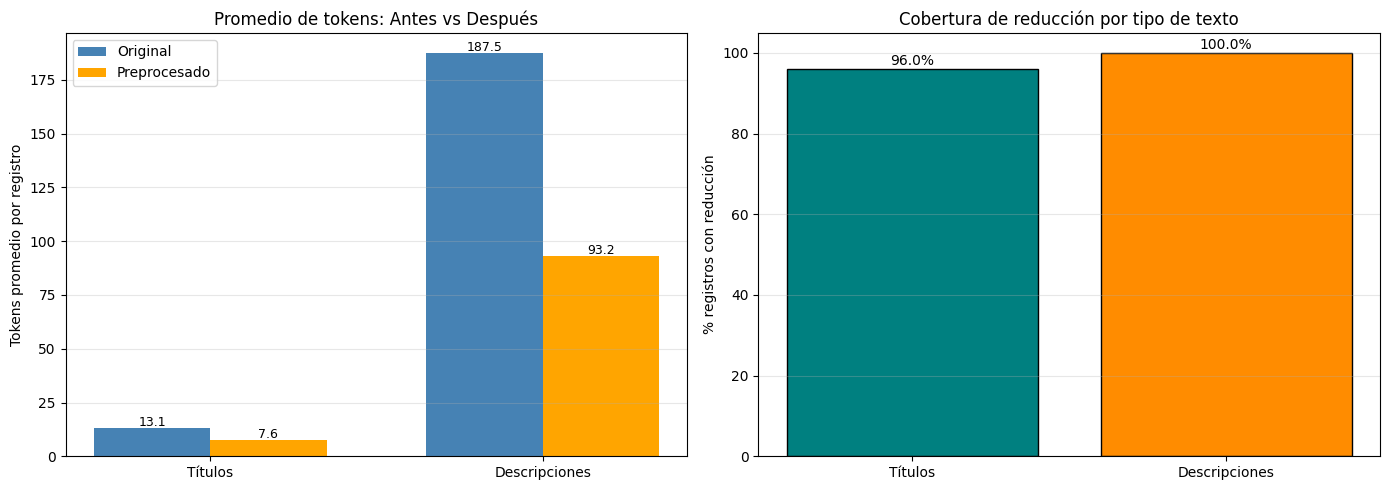


VALIDACIÓN DE DIFERENCIA ORIGINAL vs PREPROCESADO
Títulos - reducción promedio: 41.7%
Títulos - % registros con reducción: 96.0%
Descripciones - reducción promedio: 50.3%
Descripciones - % registros con reducción: 100.0%


,Campo,Muestra,Tokens originales promedio,Tokens preprocesados promedio,Reducción promedio (%),% registros con reducción
0,Títulos,500,13.05,7.61,41.70,96.0
1,Descripciones,300,187.54,93.16,50.33,100.0


In [28]:
# Visualización de reducción de tokens 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

muestra_titulos_base = productos_bogota[productos_bogota['Título original'].notna()].copy()
muestra_titulos = muestra_titulos_base.sample(
    min(500, len(muestra_titulos_base)),
    random_state=42
)

muestra_desc_base = productos_bogota[productos_bogota['Descripción original'].notna()].copy()
muestra_desc = muestra_desc_base.sample(
    min(300, len(muestra_desc_base)),
    random_state=42
)

titulos_orig_tokens = muestra_titulos['Título original'].apply(lambda x: len(str(x).split()))
titulos_clean_tokens = muestra_titulos['Título original'].apply(preprocesar_texto_completo).apply(lambda x: len(str(x).split()))
delta_titulos = titulos_orig_tokens - titulos_clean_tokens

desc_orig_tokens = muestra_desc['Descripción original'].apply(lambda x: len(str(x).split()))
desc_clean_tokens = muestra_desc['Descripción original'].apply(preprocesar_texto_completo).apply(lambda x: len(str(x).split()))
delta_desc = desc_orig_tokens - desc_clean_tokens

# =========================
# 1) BARRAS PROMEDIO ANTES vs DESPUÉS
# =========================
labels = ['Títulos', 'Descripciones']
prom_orig = [titulos_orig_tokens.mean(), desc_orig_tokens.mean()]
prom_clean = [titulos_clean_tokens.mean(), desc_clean_tokens.mean()]
x = np.arange(len(labels))
width = 0.35

axes[0].bar(x - width/2, prom_orig, width, label='Original', color='steelblue')
axes[0].bar(x + width/2, prom_clean, width, label='Preprocesado', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Tokens promedio por registro')
axes[0].set_title('Promedio de tokens: Antes vs Después')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(prom_orig):
    axes[0].text(i - width/2, v + 1, f'{v:.1f}', ha='center', fontsize=9)
for i, v in enumerate(prom_clean):
    axes[0].text(i + width/2, v + 1, f'{v:.1f}', ha='center', fontsize=9)

# =========================
# 2) % DE REGISTROS QUE REDUCEN
# =========================
pct_docs_reducidos_titulos = (delta_titulos > 0).mean() * 100
pct_docs_reducidos_desc = (delta_desc > 0).mean() * 100

axes[1].bar(
    ['Títulos', 'Descripciones'],
    [pct_docs_reducidos_titulos, pct_docs_reducidos_desc],
    color=['teal', 'darkorange'],
    edgecolor='black'
)
axes[1].set_ylim(0, 105)
axes[1].set_ylabel('% registros con reducción')
axes[1].set_title('Cobertura de reducción por tipo de texto')
axes[1].grid(axis='y', alpha=0.3)

axes[1].text(0, pct_docs_reducidos_titulos + 1, f'{pct_docs_reducidos_titulos:.1f}%', ha='center')
axes[1].text(1, pct_docs_reducidos_desc + 1, f'{pct_docs_reducidos_desc:.1f}%', ha='center')

plt.tight_layout()
plt.show()

# =========================
# RESUMEN NUMÉRICO
# =========================
pct_reduccion_titulos = (1 - titulos_clean_tokens.mean() / titulos_orig_tokens.mean()) * 100
pct_reduccion_desc = (1 - desc_clean_tokens.mean() / desc_orig_tokens.mean()) * 100

print(f"\nVALIDACIÓN DE DIFERENCIA ORIGINAL vs PREPROCESADO")
print(f"Títulos - reducción promedio: {pct_reduccion_titulos:.1f}%")
print(f"Títulos - % registros con reducción: {pct_docs_reducidos_titulos:.1f}%")
print(f"Descripciones - reducción promedio: {pct_reduccion_desc:.1f}%")
print(f"Descripciones - % registros con reducción: {pct_docs_reducidos_desc:.1f}%")

resumen_diferencia = pd.DataFrame([
    {
        'Campo': 'Títulos',
        'Muestra': len(muestra_titulos),
        'Tokens originales promedio': round(titulos_orig_tokens.mean(), 2),
        'Tokens preprocesados promedio': round(titulos_clean_tokens.mean(), 2),
        'Reducción promedio (%)': round(pct_reduccion_titulos, 2),
        '% registros con reducción': round(pct_docs_reducidos_titulos, 2)
    },
    {
        'Campo': 'Descripciones',
        'Muestra': len(muestra_desc),
        'Tokens originales promedio': round(desc_orig_tokens.mean(), 2),
        'Tokens preprocesados promedio': round(desc_clean_tokens.mean(), 2),
        'Reducción promedio (%)': round(pct_reduccion_desc, 2),
        '% registros con reducción': round(pct_docs_reducidos_desc, 2)
    }
])

display(resumen_diferencia)

## 2.12. Deep Text Analysis (Word Clouds & Token Statistics)

This section provides a deeper analysis of the textual content, focusing on the most frequent words, word clouds by language and faculty, and text quality metrics.

### 2.12.1. Word Clouds

Nube de palabras con y sin términos genéricos
Registros válidos (nube original): 108730
Registros válidos (nube informativa): 108730
Términos removidos por filtro automático (DF >= 12%): 0


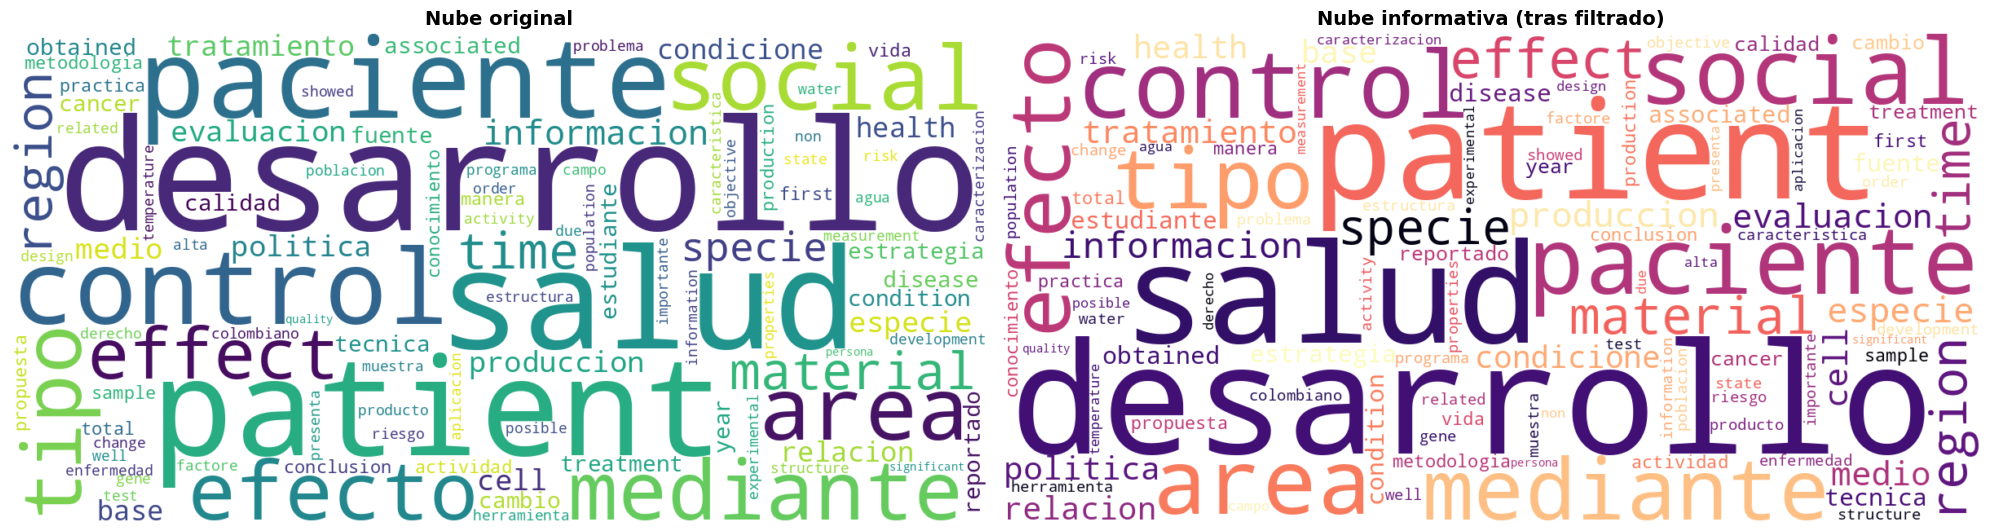

In [29]:
print("="*60)
print("Nube de palabras con y sin términos genéricos")
print("="*60)

# =========================
# 1) Construcción del texto base
# =========================
texto_base = productos_bogota.apply(
    lambda row: f"{str(row['Título original']) if pd.notna(row['Título original']) else ''} "
                f"{str(row['Descripción original']) if pd.notna(row['Descripción original']) else ''}",
    axis=1
)

texto_base = texto_base.apply(preprocesar_texto_completo)
texto_base = texto_base[texto_base.str.len() > 10].copy()

# =========================
# 2) Filtrado automático por frecuencia de documento
# =========================
umbral_df = 0.12

doc_freq = Counter()

for texto in texto_base:
    tokens = set(texto.split())
    doc_freq.update(tokens)

n_docs = len(texto_base)

stopwords_auto_df = {
    tok for tok, df in doc_freq.items()
    if (df / n_docs) >= umbral_df and len(tok) >= 2
}

# =========================
# 3) Texto informativo (aplica stopwords temáticas y automáticas)
# =========================
def limpiar_todo(texto):
    return remover_stopwords(texto, stopwords=STOPWORDS_ALL | stopwords_auto_df)

texto_info = texto_base.apply(limpiar_todo)
texto_info = texto_info[texto_info.str.len() > 10].copy()

print(f"Registros válidos (nube original): {len(texto_base)}")
print(f"Registros válidos (nube informativa): {len(texto_info)}")
print(f"Términos removidos por filtro automático (DF >= {umbral_df:.0%}): {len(stopwords_auto_df)}")

# =========================
# 5) Generación de la nube
# =========================
texto_global_original = " ".join(texto_base)
texto_global_informativo = " ".join(texto_info)

wordcloud_original = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10,
    collocations=False
).generate(texto_global_original)

wordcloud_informativo = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='magma',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10,
    collocations=False
).generate(texto_global_informativo)

# =========================
# 6) Visualización
# =========================
fig, axes = plt.subplots(1, 2, figsize=(20,7))

axes[0].imshow(wordcloud_original, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Nube original', fontsize=14, fontweight='bold')

axes[1].imshow(wordcloud_informativo, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Nube informativa (tras filtrado)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


NUBES DE PALABRAS POR FACULTAD

Publicaciones con texto válido: 108721
Ciencias: 33459 publicaciones
Medicina: 20951 publicaciones
Ingeniería: 15134 publicaciones


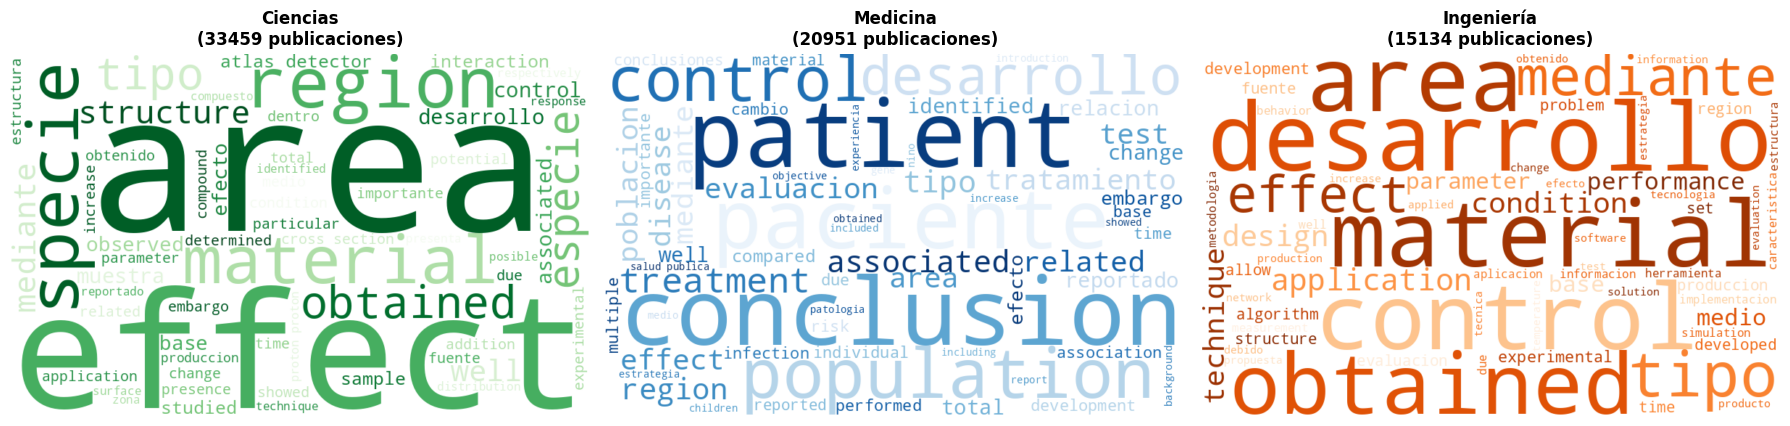

In [30]:
# ==========================================================
# NUBES DE PALABRAS POR FACULTAD (TOP 3) 
# ==========================================================

print("="*60)
print("NUBES DE PALABRAS POR FACULTAD")
print("="*60)

# ----------------------------------------------------------
# 1. Crear texto combinado
# ----------------------------------------------------------
productos_bogota['texto_completo'] = (
    productos_bogota['Título original'].fillna('').astype(str) + " " +
    productos_bogota['Descripción original'].fillna('').astype(str)
)

# ----------------------------------------------------------
# 2. Aplicar pipeline de preprocesamiento
# ----------------------------------------------------------
productos_bogota['texto_procesado'] = productos_bogota['texto_completo'].apply(
    lambda t: preprocesar_texto_completo(
        t,
        lowercase=True,
        remover_acentos=True,
        min_token_length=3,
        remover_numeros=True,
        remover_stopwords_flag=True
    )
)

# ----------------------------------------------------------
# 3. Filtrar textos válidos
# ----------------------------------------------------------
textos_validos = productos_bogota[
    productos_bogota['texto_procesado'].notna() &
    (productos_bogota['texto_procesado'].str.len() > 10)
].copy()

print(f"\nPublicaciones con texto válido: {len(textos_validos)}")

# ----------------------------------------------------------
# 4. Seleccionar las 3 facultades con más publicaciones
# ----------------------------------------------------------
top_facultades = textos_validos['Facultad'].value_counts().head(3).index

textos_por_facultad = {}

for facultad in top_facultades:

    subset = textos_validos[textos_validos['Facultad'] == facultad]

    textos = subset['texto_procesado']

    textos_filtrados = textos.apply(
        lambda t: remover_stopwords(t, stopwords=STOPWORDS_ALL | stopwords_auto_df)
    )

    textos_filtrados = textos_filtrados[textos_filtrados.str.len() > 10]

    if len(textos_filtrados) > 0:
        textos_por_facultad[facultad] = " ".join(textos_filtrados)

    print(f"{facultad}: {len(textos_filtrados)} publicaciones")

# ----------------------------------------------------------
# 5. Generar las nubes de palabras
# ----------------------------------------------------------
num_facultades = len(textos_por_facultad)

fig, axes = plt.subplots(1, num_facultades, figsize=(6 * num_facultades, 5))

if num_facultades == 1:
    axes = [axes]

colormaps = ['Greens', 'Blues', 'Oranges']

for idx, (facultad, texto) in enumerate(textos_por_facultad.items()):

    wordcloud = WordCloud(
        width=800,
        height=500,
        background_color='white',
        colormap=colormaps[idx % len(colormaps)],
        max_words=60,
        relative_scaling=0.5,
        min_font_size=10
    ).generate(texto)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')

    total_pub = len(textos_validos[textos_validos["Facultad"] == facultad])

    axes[idx].set_title(
        f"{facultad}\n({total_pub} publicaciones)",
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

ANÁLISIS DE PALABRAS MÁS FRECUENTES

Documentos analizados: 108721

Total de tokens procesados: 7,787,006
Tokens únicos: 230,647

TOP 30 PALABRAS MÁS FRECUENTES


,Palabra,Frecuencia,%
0,desarrollo,16361,0.210
1,salud,13764,0.177
2,social,12509,0.161
3,control,11978,0.154
4,mediante,11037,0.142
5,patients,10783,0.138
6,pacientes,9996,0.128
7,tipo,8936,0.115
8,species,8781,0.113
9,informacion,8378,0.108


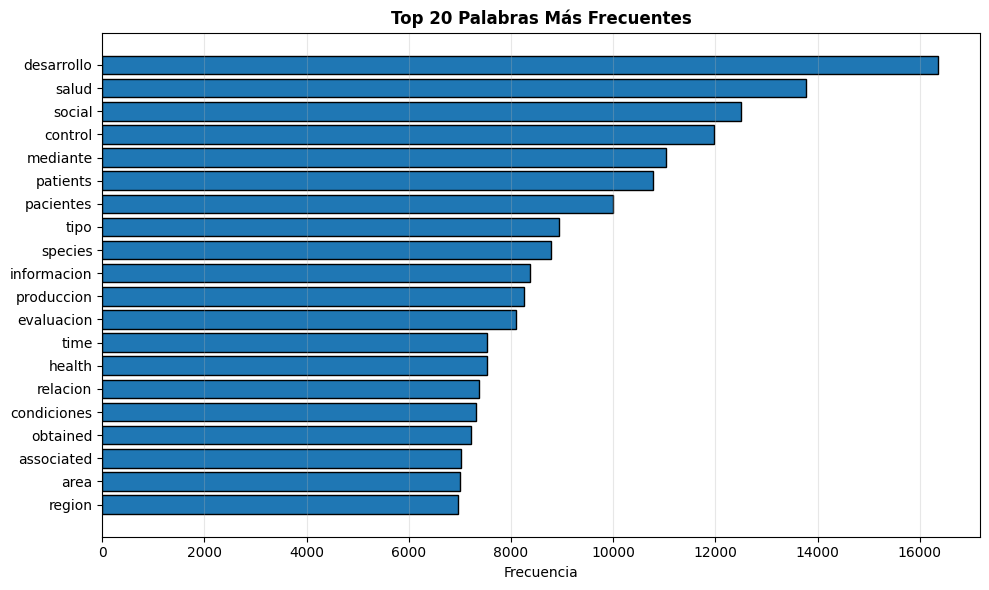

In [31]:
print("="*60)
print("ANÁLISIS DE PALABRAS MÁS FRECUENTES")
print("="*60)

# ----------------------------------------------------------
# 1. Crear columna de texto limpio si no existe
# ----------------------------------------------------------
if 'texto_limpio' not in productos_bogota.columns:

    productos_bogota['texto_completo'] = (
        productos_bogota['Título original'].fillna('').astype(str) + " " +
        productos_bogota['Descripción original'].fillna('').astype(str)
    )

    productos_bogota['texto_limpio'] = productos_bogota['texto_completo'].apply(
        lambda t: preprocesar_texto_completo(
            t,
            lowercase=True,
            remover_acentos=True,
            min_token_length=3,
            remover_numeros=True,
            remover_stopwords_flag=True
        )
    )


# ----------------------------------------------------------
# 2. Filtrar textos válidos (calidad mínima)
# ----------------------------------------------------------
textos_validos = productos_bogota[
    productos_bogota['texto_limpio'].notna() &
    (productos_bogota['texto_limpio'].str.len() > 10)
].copy()

print(f"\nDocumentos analizados: {len(textos_validos)}")


# ----------------------------------------------------------
# 3. Aplicar limpieza final (stopwords adicionales)
# ----------------------------------------------------------
textos_analisis = textos_validos['texto_limpio'].apply(
    lambda t: remover_stopwords(t, stopwords=STOPWORDS_ALL | stopwords_auto_df)
)


# ----------------------------------------------------------
# 4. Extraer tokens
# ----------------------------------------------------------
todos_tokens = []

for texto in textos_analisis:
    if texto and len(texto) > 0:
        todos_tokens.extend(texto.split())

print(f"\nTotal de tokens procesados: {len(todos_tokens):,}")
print(f"Tokens únicos: {len(set(todos_tokens)):,}")


# ----------------------------------------------------------
# 5. Frecuencia de palabras
# ----------------------------------------------------------
counter_tokens = Counter(todos_tokens)

top_30 = counter_tokens.most_common(30)

print("\nTOP 30 PALABRAS MÁS FRECUENTES")

top_30_df = pd.DataFrame(top_30, columns=['Palabra', 'Frecuencia'])
top_30_df['%'] = (top_30_df['Frecuencia'] / len(todos_tokens) * 100).round(3)

display(top_30_df)


# ----------------------------------------------------------
# 6. Visualización: Top palabras
# ----------------------------------------------------------
top_20_df = top_30_df.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top_20_df['Palabra'][::-1],
    top_20_df['Frecuencia'][::-1],
    edgecolor='black'
)

plt.xlabel("Frecuencia")
plt.title("Top 20 Palabras Más Frecuentes", fontweight="bold")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### 2.12.2. Text Quality Analysis

ANÁLISIS DE CALIDAD DE TEXTO

📊 MÉTRICAS DE CALIDAD

TÍTULOS
Sin contenido útil (0 tokens): 91 (0.1%)
Muy cortos (1-2 tokens): 6789 (6.2%)

DESCRIPCIONES
Sin contenido útil (0 tokens): 40816 (37.2%)
Muy cortas (1-9 tokens): 6684 (6.1%)

Registros con texto completo de buena calidad
60801 / 109836 (55.4%)


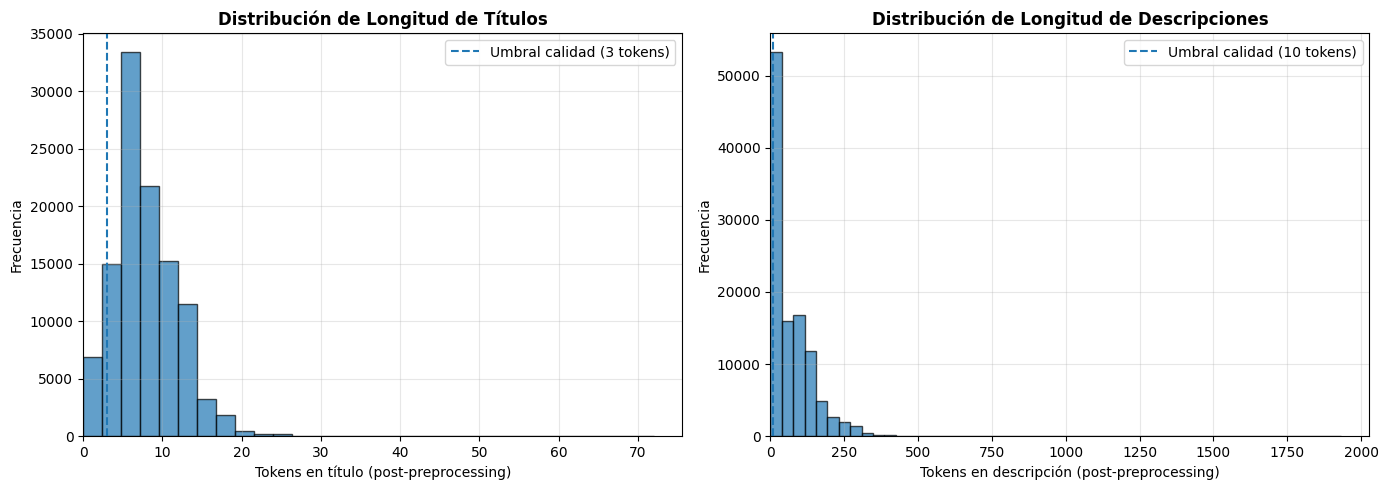


⚠️ EJEMPLOS DE REGISTROS CON DESCRIPCIÓN MUY CORTA O VACÍA


,Título original,Descripción original
10,Characterization of manual filters for irrigat...,NaN
28,Calling for synergized strategies to monitor a...,NaN
40,Editorial for special issue on ADRC: new ADRC ...,NaN
60,Development of Structural Type Mortars Reinfor...,NaN
71,Energy efficient alternatives to decarbonize t...,NaN
72,Drought Risk Analysis for Panela Sugarcane Pro...,NaN
73,Water Thermal Regime of River-Floodplain Syste...,NaN
76,Evaluation of the hydrological response of the...,NaN
81,EFECTO DE LA VARIABILIDAD CLIMÁTICA EN PRODUCC...,No Reportado
86,Artificial intelligence in engineering educati...,NaN


In [32]:
if 'productos_bogota' not in globals():
    try:
        productos_bogota = df.copy()
        print("⚠️ 'productos_bogota' no existía. Se creó a partir de 'df'.")
    except:
        raise ValueError("No existe el dataframe 'productos_bogota' ni 'df'. Debes cargar tus datos primero.")

# ----------------------------------------------------------
# Verificar columnas necesarias
# ----------------------------------------------------------
required_columns = ['Título original', 'Descripción original']
for col in required_columns:
    if col not in productos_bogota.columns:
        raise ValueError(f"La columna '{col}' no existe en el dataframe.")

# ----------------------------------------------------------
print("ANÁLISIS DE CALIDAD DE TEXTO")
print("="*60)

# ----------------------------------------------------------
# 1. Calcular tokens de títulos
# ----------------------------------------------------------
productos_bogota['titulo_tokens'] = (
    productos_bogota['Título original']
    .fillna('')
    .astype(str)
    .apply(lambda x: len(preprocesar_texto_completo(x).split()) if x.strip() else 0)
)

# ----------------------------------------------------------
# 2. Calcular tokens de descripciones
# ----------------------------------------------------------
productos_bogota['desc_tokens'] = (
    productos_bogota['Descripción original']
    .fillna('')
    .astype(str)
    .apply(lambda x: len(preprocesar_texto_completo(x).split()) if x.strip() else 0)
)

# ----------------------------------------------------------
# 3. Métricas de calidad
# ----------------------------------------------------------
total_registros = len(productos_bogota)

titulo_vacio = (productos_bogota['titulo_tokens'] == 0).sum()
titulo_muy_corto = (
    (productos_bogota['titulo_tokens'] > 0) &
    (productos_bogota['titulo_tokens'] < 3)
).sum()

desc_vacia = (productos_bogota['desc_tokens'] == 0).sum()
desc_muy_corta = (
    (productos_bogota['desc_tokens'] > 0) &
    (productos_bogota['desc_tokens'] < 10)
).sum()

print(f"\n📊 MÉTRICAS DE CALIDAD")

print(f"\nTÍTULOS")
print(f"Sin contenido útil (0 tokens): {titulo_vacio} ({titulo_vacio/total_registros*100:.1f}%)")
print(f"Muy cortos (1-2 tokens): {titulo_muy_corto} ({titulo_muy_corto/total_registros*100:.1f}%)")

print(f"\nDESCRIPCIONES")
print(f"Sin contenido útil (0 tokens): {desc_vacia} ({desc_vacia/total_registros*100:.1f}%)")
print(f"Muy cortas (1-9 tokens): {desc_muy_corta} ({desc_muy_corta/total_registros*100:.1f}%)")

# ----------------------------------------------------------
# 4. Registros de buena calidad
# ----------------------------------------------------------
buena_calidad = (
    (productos_bogota['titulo_tokens'] >= 3) &
    (productos_bogota['desc_tokens'] >= 10)
).sum()

print(f"\nRegistros con texto completo de buena calidad")
print(f"{buena_calidad} / {total_registros} ({buena_calidad/total_registros*100:.1f}%)")

# ----------------------------------------------------------
# 5. Visualizaciones
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de títulos
axes[0].hist(
    productos_bogota['titulo_tokens'],
    bins=30,
    edgecolor='black',
    alpha=0.7
)

axes[0].axvline(x=3, linestyle='--', label='Umbral calidad (3 tokens)')
axes[0].set_xlabel('Tokens en título (post-preprocessing)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Longitud de Títulos', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(left=0)

# Distribución descripciones
axes[1].hist(
    productos_bogota['desc_tokens'],
    bins=50,
    edgecolor='black',
    alpha=0.7
)

axes[1].axvline(x=10, linestyle='--', label='Umbral calidad (10 tokens)')
axes[1].set_xlabel('Tokens en descripción (post-preprocessing)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Longitud de Descripciones', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(left=0)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 6. Ejemplos problemáticos
# ----------------------------------------------------------
print("\n⚠️ EJEMPLOS DE REGISTROS CON DESCRIPCIÓN MUY CORTA O VACÍA")

casos_problematicos = productos_bogota[
    productos_bogota['desc_tokens'] < 10
][['Título original', 'Descripción original']].head(10)

display(casos_problematicos)

# ----------------------------------------------------------
# 7. Limpiar columnas temporales
# ----------------------------------------------------------
productos_bogota.drop(columns=['titulo_tokens', 'desc_tokens'], inplace=True)

## 2.13. Cross Analysis: Language × Text × Active Coauthors

ANÁLISIS CRUZADO: IDIOMA × TEXTO × COAUTORES ACTIVOS



📊 RESUMEN POR IDIOMA:


,titulo_mean,titulo_median,desc_mean,desc_median,activos_mean,activos_median,activos_max,n_publicaciones
Idioma,,,,,,,,
Español,7.80,7.0,67.95,26.0,1.21,1.0,48,60001
Inglés,8.70,8.0,78.71,79.0,1.27,1.0,9,37254
Portugués,4.23,3.0,15.86,1.0,1.10,1.0,8,1119
Galicia,4.08,3.0,0.62,0.0,1.14,1.0,7,1110
Indonesio,5.51,5.0,1.81,0.0,1.18,1.0,4,632


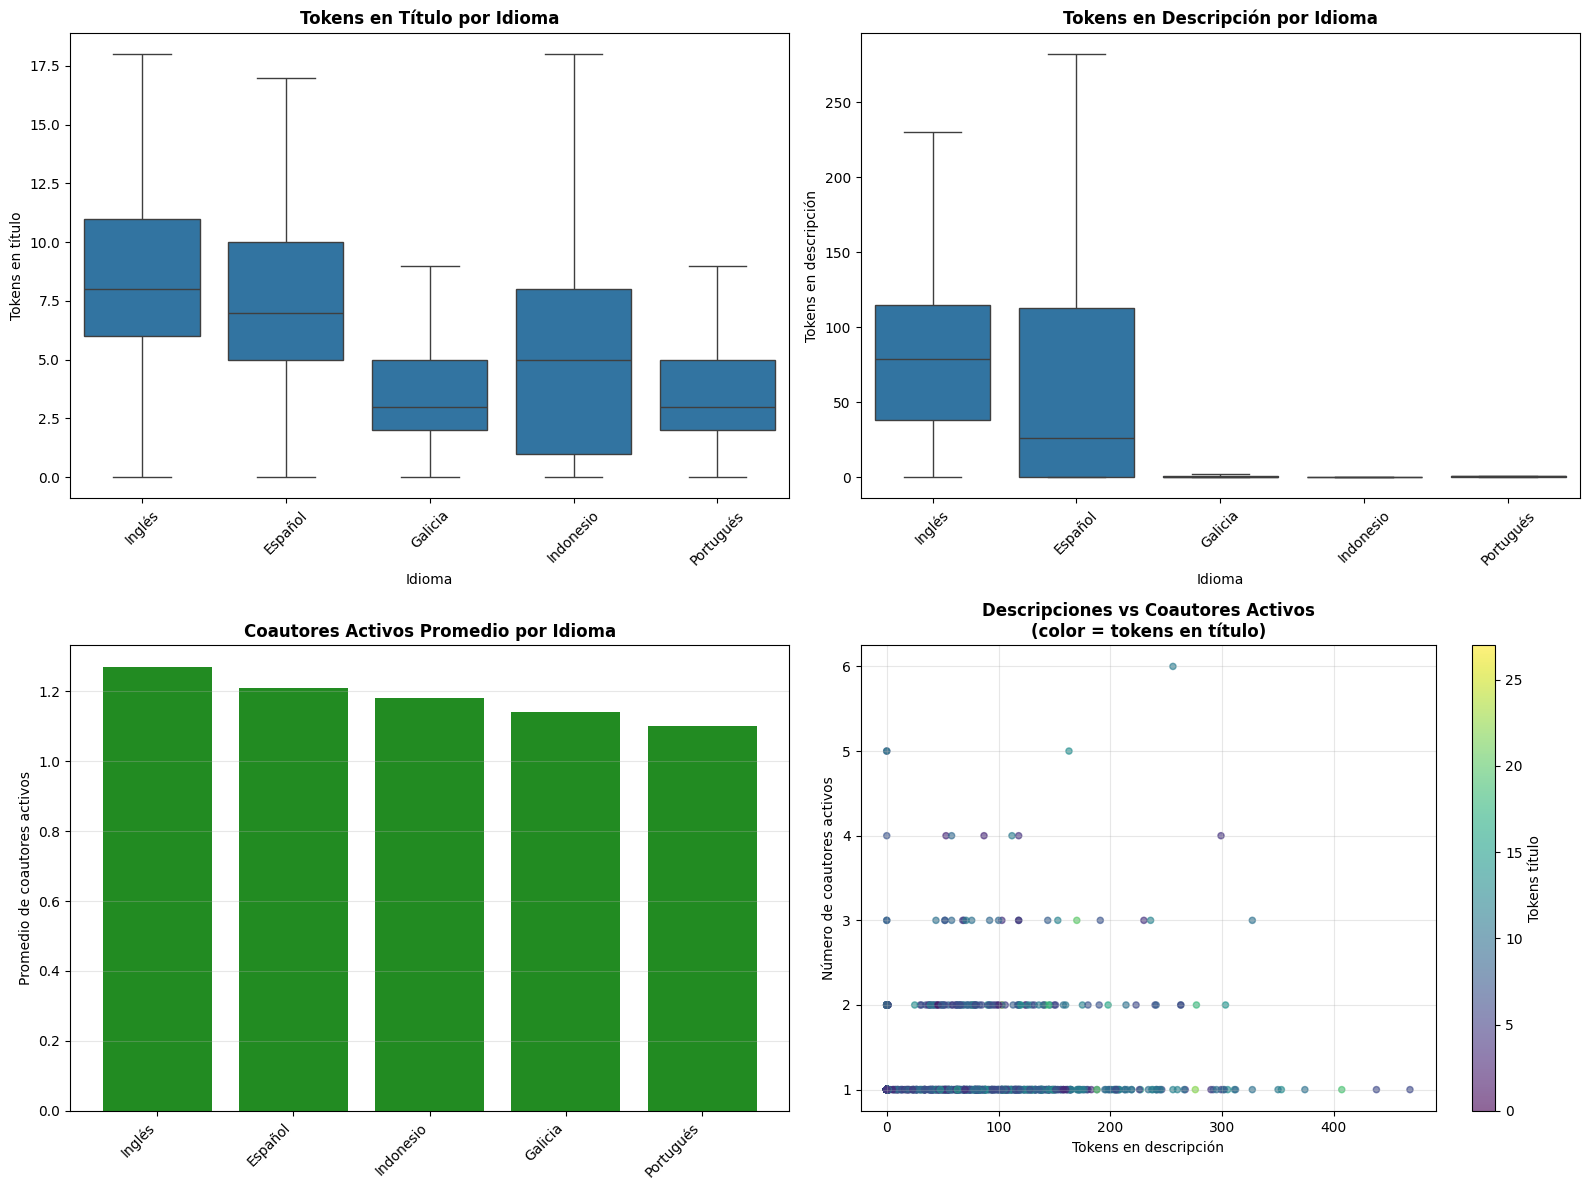


🔍 HALLAZGOS CLAVE:
1. Idioma con descripciones más largas (promedio): Inglés (78.7 tokens)
2. Idioma con más coautores activos por publicación: Inglés (1.27)


In [33]:
print("="*60)
print("ANÁLISIS CRUZADO: IDIOMA × TEXTO × COAUTORES ACTIVOS")
print("="*60)

# Crear variables auxiliares
cross_df = productos_bogota.copy()

# Longitud de texto (tokens procesados)
cross_df['titulo_tokens_clean'] = cross_df['Título original'].fillna('').astype(str).apply(
    lambda x: len(preprocesar_texto_completo(x).split()) if x.strip() else 0
)
cross_df['desc_tokens_clean'] = cross_df['Descripción original'].fillna('').astype(str).apply(
    lambda x: len(preprocesar_texto_completo(x).split()) if x.strip() else 0
)

# Número de coautores activos por publicación
def contar_activos_en_paper(coautores_str, docentes_set):
    nombres = extraer_coautores(coautores_str)
    return sum(1 for n in nombres if normalizar_para_match(n) in docentes_set)

cross_df['num_activos'] = cross_df['Coautores'].apply(
    lambda x: contar_activos_en_paper(x, docentes_activos_nombres)
)

# Filtrar idiomas principales
idiomas_top = cross_df['Idioma'].value_counts().head(5).index
cross_top = cross_df[cross_df['Idioma'].isin(idiomas_top)].copy()

print("\n📊 RESUMEN POR IDIOMA:")
resumen_idioma = cross_top.groupby('Idioma').agg({
    'titulo_tokens_clean': ['mean', 'median'],
    'desc_tokens_clean': ['mean', 'median'],
    'num_activos': ['mean', 'median', 'max'],
    'Idioma': 'count'
}).round(2)

resumen_idioma.columns = ['titulo_mean', 'titulo_median', 'desc_mean', 'desc_median', 
                          'activos_mean', 'activos_median', 'activos_max', 'n_publicaciones']
resumen_idioma = resumen_idioma.sort_values('n_publicaciones', ascending=False)
display(resumen_idioma)

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Boxplot de longitud de título por idioma
sns.boxplot(data=cross_top, x='Idioma', y='titulo_tokens_clean', ax=axes[0, 0], showfliers=False)
axes[0, 0].set_title('Tokens en Título por Idioma', fontweight='bold')
axes[0, 0].set_xlabel('Idioma')
axes[0, 0].set_ylabel('Tokens en título')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Boxplot de longitud de descripción por idioma
sns.boxplot(data=cross_top, x='Idioma', y='desc_tokens_clean', ax=axes[0, 1], showfliers=False)
axes[0, 1].set_title('Tokens en Descripción por Idioma', fontweight='bold')
axes[0, 1].set_xlabel('Idioma')
axes[0, 1].set_ylabel('Tokens en descripción')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Coautores activos promedio por idioma
activos_por_idioma = cross_top.groupby('Idioma')['num_activos'].mean().sort_values(ascending=False)
axes[1, 0].bar(range(len(activos_por_idioma)), activos_por_idioma.values, color='forestgreen')
axes[1, 0].set_xticks(range(len(activos_por_idioma)))
axes[1, 0].set_xticklabels(activos_por_idioma.index, rotation=45, ha='right')
axes[1, 0].set_title('Coautores Activos Promedio por Idioma', fontweight='bold')
axes[1, 0].set_ylabel('Promedio de coautores activos')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Scatter: longitud descripción vs coautores activos
sample_cross = cross_top.sample(min(1000, len(cross_top)), random_state=42)
scatter = axes[1, 1].scatter(sample_cross['desc_tokens_clean'], sample_cross['num_activos'], 
                             c=sample_cross['titulo_tokens_clean'], cmap='viridis', alpha=0.6, s=20)
axes[1, 1].set_title('Descripciones vs Coautores Activos\n(color = tokens en título)', fontweight='bold')
axes[1, 1].set_xlabel('Tokens en descripción')
axes[1, 1].set_ylabel('Número de coautores activos')
axes[1, 1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='Tokens título')

plt.tight_layout()
plt.show()

# Hallazgos clave
print("\n🔍 HALLAZGOS CLAVE:")
idioma_mas_largo = resumen_idioma['desc_mean'].idxmax()
print(f"1. Idioma con descripciones más largas (promedio): {idioma_mas_largo} ({resumen_idioma.loc[idioma_mas_largo, 'desc_mean']:.1f} tokens)")

idioma_mas_colaborativo = resumen_idioma['activos_mean'].idxmax()
print(f"2. Idioma con más coautores activos por publicación: {idioma_mas_colaborativo} ({resumen_idioma.loc[idioma_mas_colaborativo, 'activos_mean']:.2f})")

# Limpiar columnas temporales
del cross_df, cross_top

## 2.14. Secondary Analysis linked to core variables (Faculty × Missing Text)

ANÁLISIS: FACULTAD × FALTA DE DESCRIPCIÓN

📊 Porcentaje de descripciones faltantes o no útiles por facultad:


,Facultad,total_publicaciones,desc_faltantes_o_cortas,porcentaje_faltante
0,Artes,7640,5090,66.62
5,Derecho,4268,2327,54.52
10,Veterinaria,3256,1705,52.36
4,Ciencias Humanas,10415,5448,52.31
8,Medicina,21115,9758,46.21
9,Odontología,2733,1258,46.03
3,Ciencias Económicas,3758,1602,42.63
2,Ciencias Agrarias,4884,1863,38.14
1,Ciencias,33701,12465,36.99
6,Enfermería,2838,983,34.64



🎨 Hipótesis Facultad de Artes:
   % faltante en Artes: 66.62%
   % promedio general: 45.75%
   ✅ Artes está por ENCIMA del promedio (+20.87 pp)


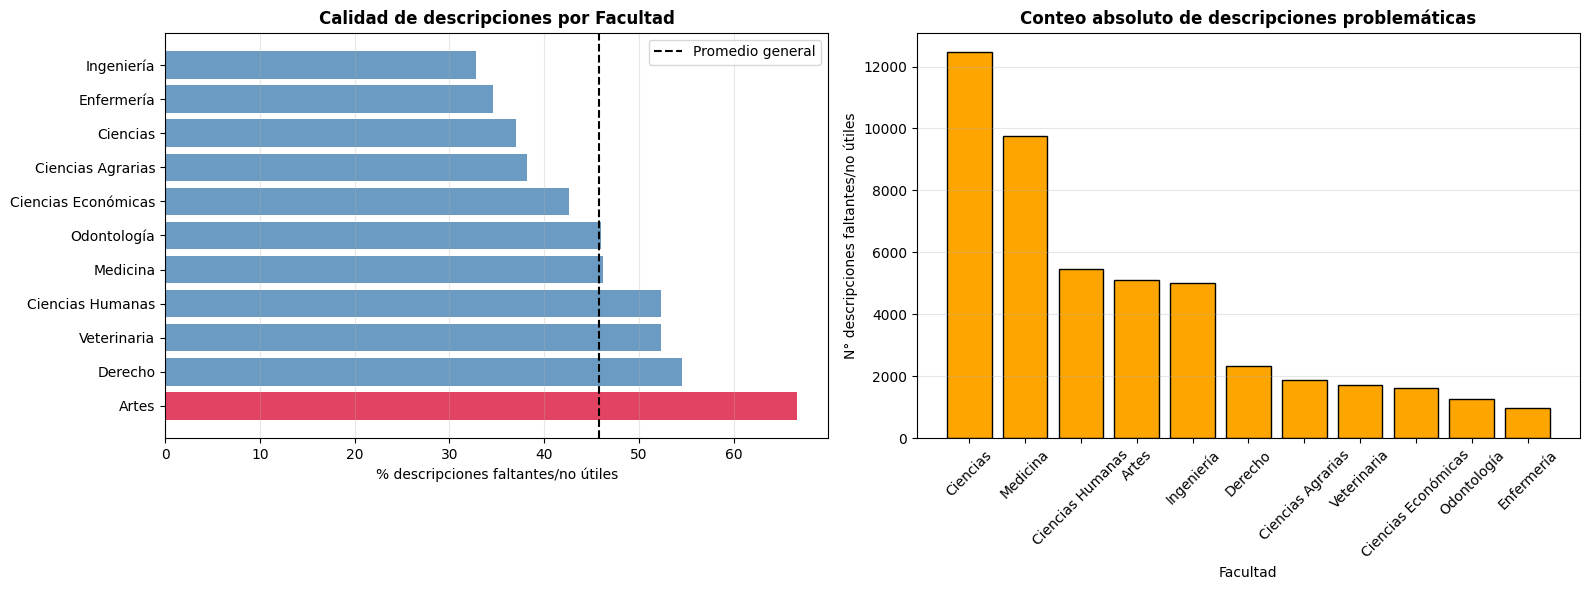


🌐 Cruce Facultad × Idioma (solo registros con descripción útil):


Idioma,Alemán,Catalán,Español,Estonia,Francés,Galicia,Holandés,Indonesio,Inglés,Italiano,Latin,Lituano,Portugués,Rumania,Turco
Facultad,,,,,,,,,,,,,,,
Artes,0.0,0.0,87.8,0.0,0.3,0.0,0.0,0.0,11.7,0.1,0.0,0.0,0.0,0.0,0.0
Ciencias,0.0,0.0,40.9,0.0,0.0,0.0,0.0,0.0,58.9,0.0,0.0,0.0,0.1,0.0,0.0
Ciencias Agrarias,0.0,0.0,51.3,0.0,0.0,0.0,0.0,0.1,48.3,0.0,0.0,0.0,0.2,0.0,0.0
Ciencias Económicas,0.0,0.0,52.2,0.0,0.3,0.0,0.0,0.0,47.3,0.0,0.0,0.0,0.2,0.0,0.0
Ciencias Humanas,0.1,0.0,73.2,0.0,0.5,0.1,0.0,0.0,25.7,0.1,0.0,0.0,0.3,0.0,0.0
Derecho,0.2,0.1,90.5,0.0,0.3,0.1,0.0,0.0,8.7,0.0,0.0,0.0,0.4,0.0,0.0
Enfermería,0.0,0.0,69.1,0.0,0.0,0.0,0.0,0.0,30.4,0.0,0.0,0.0,0.5,0.0,0.0
Ingeniería,0.1,0.0,45.7,0.0,0.1,0.0,0.0,0.0,54.0,0.0,0.0,0.0,0.1,0.0,0.0
Medicina,0.0,0.0,47.9,0.0,0.0,0.0,0.0,0.1,51.7,0.0,0.0,0.0,0.1,0.0,0.0


In [34]:
print("="*60)
print("ANÁLISIS: FACULTAD × FALTA DE DESCRIPCIÓN")
print("="*60)

# Definir qué se considera descripción faltante/no útil
def descripcion_faltante(desc):
    if pd.isna(desc):
        return True
    desc_str = str(desc).strip()
    if desc_str == '' or es_valor_nulo_convencion(desc_str):
        return True
    # También considerar muy cortas como no útiles
    desc_clean = preprocesar_texto_completo(desc_str)
    return len(desc_clean.split()) < 10

productos_bogota['desc_faltante_o_corta'] = productos_bogota['Descripción original'].apply(descripcion_faltante)

# Resumen por facultad
resumen_fac_desc = productos_bogota.groupby('Facultad').agg(
    total_publicaciones=('Facultad', 'count'),
    desc_faltantes_o_cortas=('desc_faltante_o_corta', 'sum')
).reset_index()

resumen_fac_desc['porcentaje_faltante'] = (
    resumen_fac_desc['desc_faltantes_o_cortas'] / resumen_fac_desc['total_publicaciones'] * 100
).round(2)

resumen_fac_desc = resumen_fac_desc.sort_values('porcentaje_faltante', ascending=False)

print("\n📊 Porcentaje de descripciones faltantes o no útiles por facultad:")
display(resumen_fac_desc)

# Test específico de hipótesis (Facultad de Artes)
if 'Artes' in resumen_fac_desc['Facultad'].values:
    artes_pct = resumen_fac_desc[resumen_fac_desc['Facultad'] == 'Artes']['porcentaje_faltante'].iloc[0]
    promedio_general = resumen_fac_desc['porcentaje_faltante'].mean()
    
    print(f"\n🎨 Hipótesis Facultad de Artes:")
    print(f"   % faltante en Artes: {artes_pct:.2f}%")
    print(f"   % promedio general: {promedio_general:.2f}%")
    
    if artes_pct > promedio_general:
        print(f"   ✅ Artes está por ENCIMA del promedio (+{artes_pct - promedio_general:.2f} pp)")
    else:
        print(f"   ℹ️ Artes está por DEBAJO del promedio ({artes_pct - promedio_general:.2f} pp)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: % faltante por facultad
colors = ['crimson' if f == 'Artes' else 'steelblue' for f in resumen_fac_desc['Facultad']]
axes[0].barh(resumen_fac_desc['Facultad'], resumen_fac_desc['porcentaje_faltante'], color=colors, alpha=0.8)
axes[0].axvline(x=resumen_fac_desc['porcentaje_faltante'].mean(), color='black', linestyle='--', label='Promedio general')
axes[0].set_xlabel('% descripciones faltantes/no útiles')
axes[0].set_title('Calidad de descripciones por Facultad', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Gráfico 2: Conteos absolutos
df_plot = resumen_fac_desc.sort_values('desc_faltantes_o_cortas', ascending=False)
axes[1].bar(df_plot['Facultad'], df_plot['desc_faltantes_o_cortas'], color='orange', edgecolor='black')
axes[1].set_xlabel('Facultad')
axes[1].set_ylabel('N° descripciones faltantes/no útiles')
axes[1].set_title('Conteo absoluto de descripciones problemáticas', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Relación con idioma
print("\n🌐 Cruce Facultad × Idioma (solo registros con descripción útil):")
productos_utiles = productos_bogota[~productos_bogota['desc_faltante_o_corta']]
facultad_idioma_usable = pd.crosstab(
    productos_utiles['Facultad'],
    productos_utiles['Idioma'],
    normalize='index'
).round(3) * 100

display(facultad_idioma_usable)

# Limpiar columna temporal
productos_bogota.drop(columns=['desc_faltante_o_corta'], inplace=True)

## 2.15. Executive Summary (Text, Active Coauthors, Language Focus)

In [35]:
# Resumen final del EDA (enfoque en texto, coautores activos e idioma)
print("RESUMEN EJECUTIVO DEL EDA - ENFOQUE PRINCIPAL")

# Métricas base de texto
titulos_validos = productos_bogota['Título original'].notna().sum()
desc_validas = productos_bogota['Descripción original'].notna().sum()

titulos_tokens = productos_bogota['Título original'].fillna('').astype(str).apply(
    lambda x: len(preprocesar_texto_completo(x).split()) if x.strip() else 0
)
desc_tokens = productos_bogota['Descripción original'].fillna('').astype(str).apply(
    lambda x: len(preprocesar_texto_completo(x).split()) if x.strip() else 0
)

# Métricas de coautores activos
papers_con_activos = productos_bogota['Coautores'].apply(
    lambda x: tiene_docente_activo(x, docentes_activos_nombres)
).sum()

# Distribución idiomas principal
idioma_dist = productos_bogota['Idioma'].value_counts(dropna=False)
idioma_top = idioma_dist.head(5)

resumen = f"""
DATASET:
  - {len(productos_bogota)} registros de producciones académicas

FOCO 1: VARIABLES DE TEXTO
  - Registros con título no nulo: {titulos_validos} ({titulos_validos/len(productos_bogota)*100:.1f}%)
  - Registros con descripción no nula: {desc_validas} ({desc_validas/len(productos_bogota)*100:.1f}%)
  - Longitud promedio título (post-preprocessing): {titulos_tokens.mean():.2f} tokens
  - Longitud promedio descripción (post-preprocessing): {desc_tokens.mean():.2f} tokens
  - Títulos muy cortos (<3 tokens): {(titulos_tokens < 3).sum()} ({(titulos_tokens < 3).sum()/len(productos_bogota)*100:.1f}%)
  - Descripciones no útiles (<10 tokens): {(desc_tokens < 10).sum()} ({(desc_tokens < 10).sum()/len(productos_bogota)*100:.1f}%)

FOCO 2: COAUTORES ACTIVOS
  - Producciones con al menos 1 docente activo: {papers_con_activos} ({papers_con_activos/len(productos_bogota)*100:.1f}%)
  - Promedio de coautores por producción (general): {productos_bogota['num_coautores'].mean():.2f}
  - Hallazgo: se filtraron colaboradores no docentes para análisis de frecuencia principal

FOCO 3: IDIOMA
  - Idiomas detectados (incluyendo nulos): {productos_bogota['Idioma'].nunique(dropna=False)}
  - Registros sin idioma especificado: {productos_bogota['Idioma'].isna().sum()} ({productos_bogota['Idioma'].isna().sum()/len(productos_bogota)*100:.1f}%)
  - Top 5 idiomas por frecuencia:
{idioma_top.to_string()}

ANÁLISIS RELACIONADOS (SECUNDARIOS, CONECTADOS AL FOCO)
  - Facultad × descripción faltante/no útil: evaluado para identificar posibles sesgos de captura
  - Idioma × longitud de texto × coautores activos: evaluado en análisis cruzado

CONCLUSIÓN OPERATIVA PARA SIGUIENTE FASE (PREPROCESSING NOTEBOOK)
  1. Priorizar registros con descripción útil para topic modeling.
  2. Mantener títulos como respaldo cuando no hay descripción.
  3. Usar filtro de docentes activos para métricas de autoría principal.
  4. Tratar explícitamente registros sin idioma (heurística o detección automática).
"""

print(resumen)

RESUMEN EJECUTIVO DEL EDA - ENFOQUE PRINCIPAL

DATASET:
  - 109836 registros de producciones académicas

FOCO 1: VARIABLES DE TEXTO
  - Registros con título no nulo: 109835 (100.0%)
  - Registros con descripción no nula: 69928 (63.7%)
  - Longitud promedio título (post-preprocessing): 7.86 tokens
  - Longitud promedio descripción (post-preprocessing): 64.24 tokens
  - Títulos muy cortos (<3 tokens): 6880 (6.3%)
  - Descripciones no útiles (<10 tokens): 47500 (43.2%)

FOCO 2: COAUTORES ACTIVOS
  - Producciones con al menos 1 docente activo: 109836 (100.0%)
  - Promedio de coautores por producción (general): 26.98
  - Hallazgo: se filtraron colaboradores no docentes para análisis de frecuencia principal

FOCO 3: IDIOMA
  - Idiomas detectados (incluyendo nulos): 31
  - Registros sin idioma especificado: 7733 (7.0%)
  - Top 5 idiomas por frecuencia:
Idioma
Español      60001
Inglés       37254
NaN           7733
Portugués     1119
Galicia       1110

ANÁLISIS RELACIONADOS (SECUNDARIOS, CON